### imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v7.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,logHI_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,floa

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/paper_plots/final/gaussian_fits/'

In [6]:
# ellipticals = master_table[master_table['Mvir'] > 0]
# ellipticals = ellipticals[ellipticals['sphd_M_star'] > 0]
# spirals = master_table[master_table['v_max'] > 0]
# spirals = spirals[spirals['M90_disk'] > 0]
# spirals = spirals[spirals['alpha'] <= 99]
# spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
# v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
# all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
# spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [49]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [50]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [7]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [8]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [9]:
def lin_fit(x, a, b):

    return a*x + b

In [10]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [11]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


## mstar & mtot vs mr within r90 by cmd

In [12]:
#define bins

mr_bins =  np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])])-0.01,
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)


#### ellipticals

In [13]:
# ellipticals
e_mr_ctrs = []
e_mstar = []
e_mtot = []
e_mr_bins = np.concatenate((mr_bins[0:10], mr_bins[-1:]))

indices = np.digitize(ellipticals['rabsmag'], e_mr_bins, right=True)

for i in range(1,len(e_mr_bins)):

    e_mstar.append(ellipticals['e_M_star_R90_h'][indices==i])
    e_mtot.append(ellipticals['Mvir'][indices==i])
    e_mr_ctrs.append(np.mean(ellipticals['rabsmag'][indices==i]))

e_mstar_avg, e_mstar_sig = fit_to_gaussian(e_mstar, plot_dir = plot_dir + '/ellipticals_mr/', plot_name='ellipticals_Mstar90_Mr', xlab=r'$M_*$')
e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + '/ellipticals_mr/', plot_name='ellipticals_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

e_mstar_popt, e_mstar_pcov = curve_fit(lin_fit, e_mr_ctrs, 
                                       e_mstar_avg, sigma=e_mstar_sig)
e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mr_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mstar_popt, np.sqrt(e_mstar_pcov[0,0]), np.sqrt(e_mstar_pcov[1,1]))
print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[-0.39329401  2.68201554] 0.006166646884338967 0.13114408452998325
[-0.50001051  0.76753654] 0.012877560105461946 0.2745487928434646


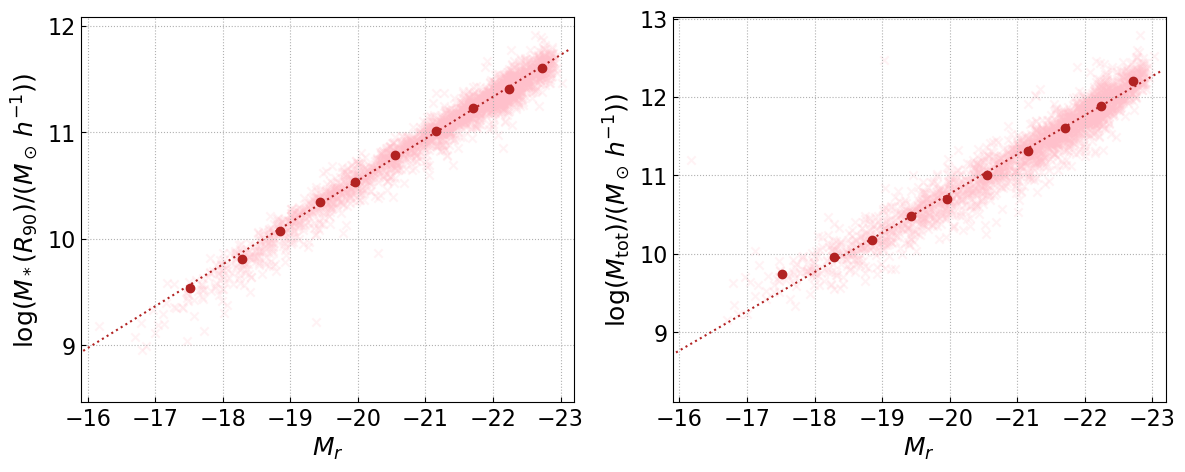

In [14]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], marker='x', color='pink', alpha=0.2)
ax[1].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], marker='x', color='pink', alpha=0.2)
ax[0].errorbar(e_mr_ctrs, e_mstar_avg, yerr=e_mstar_sig, color='firebrick', linestyle='none', marker='o')
ax[1].errorbar(e_mr_ctrs, e_mtot_avg, yerr=e_mtot_sig, color='firebrick', linestyle='none', marker='o')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(e_mr_bins, e_mr_bins*e_mstar_popt[0] + e_mstar_popt[1], linestyle=':', color='firebrick')
ax[1].plot(e_mr_bins, e_mr_bins*e_mtot_popt[0] + e_mtot_popt[1], linestyle=':', color='firebrick')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### blue spirals

In [15]:
bs_mr_ctrs = []
bs_mstar = []
bs_mtot = []
bs_mr_bins = mr_bins
bs_mr_bins = np.concatenate((mr_bins[:1], mr_bins[2:-4], mr_bins[-1:]))

indices = np.digitize(blue_spirals['rabsmag'], bs_mr_bins, right=True)

for i in range(1,len(bs_mr_bins)):

    bs_mstar.append(blue_spirals['M90_disk_h'][indices==i])
    bs_mtot.append(blue_spirals['M_R90'][indices==i])
    bs_mr_ctrs.append(np.mean(blue_spirals['rabsmag'][indices==i]))

bs_mstar_avg, bs_mstar_sig = fit_to_gaussian(bs_mstar, plot_dir = plot_dir + '/bs_mr/', plot_name='bs_Mstar90_Mr', xlab=r'$M_*$')
bs_mtot_avg, bs_mtot_sig = fit_to_gaussian(bs_mtot, plot_dir = plot_dir + '/bs_mr/', plot_name='bs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

bs_mstar_popt, bs_mstar_pcov = curve_fit(lin_fit, bs_mr_ctrs, 
                                       bs_mstar_avg, sigma=bs_mstar_sig)
bs_mtot_popt, bs_mtot_pcov = curve_fit(lin_fit, bs_mr_ctrs, 
                                       bs_mtot_avg, sigma=bs_mtot_sig)

print(bs_mstar_popt, np.sqrt(bs_mstar_pcov[0,0]), np.sqrt(bs_mstar_pcov[1,1]))
print(bs_mtot_popt, np.sqrt(bs_mtot_pcov[0,0]), np.sqrt(bs_mtot_pcov[1,1]))

[-0.44465888  1.36229108] 0.005382415147359365 0.10620911629202506
[-0.36172385  3.57845627] 0.009653061183546403 0.1906890521729624


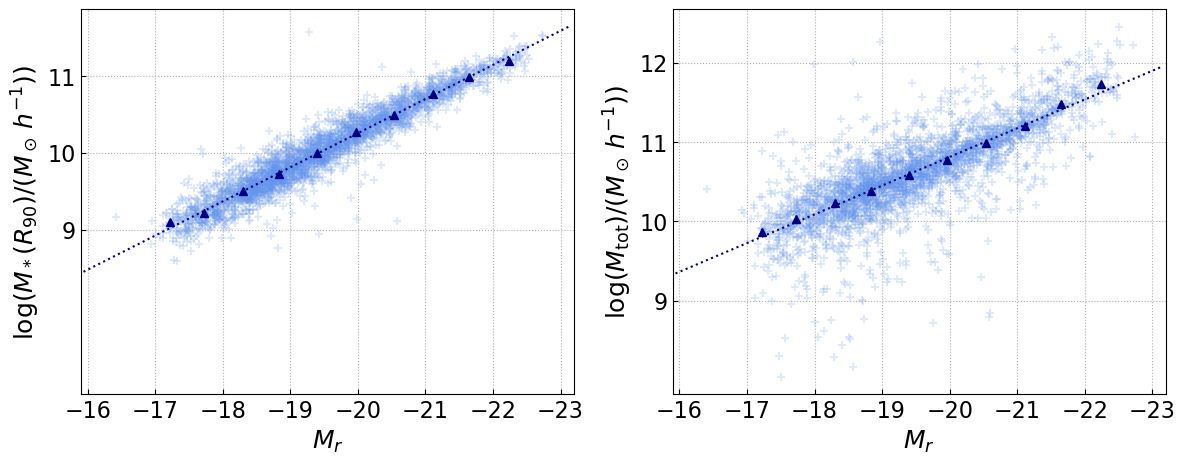

In [16]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk_h'], marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(bs_mr_ctrs, bs_mstar_avg, yerr=bs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(bs_mr_ctrs, bs_mtot_avg, yerr=bs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*bs_mstar_popt[0] + bs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*bs_mtot_popt[0] + bs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### green spirals

In [17]:
gs_mr_ctrs = []
gs_mstar = []
gs_mtot = []
gs_mr_bins = np.concatenate((mr_bins[:1], mr_bins[3:10], mr_bins[-1:]))

indices = np.digitize(green_spirals['rabsmag'], gs_mr_bins, right=True)

for i in range(1,len(gs_mr_bins)):

    gs_mstar.append(green_spirals['M90_disk_h'][indices==i])
    gs_mtot.append(green_spirals['M_R90'][indices==i])
    gs_mr_ctrs.append(np.mean(green_spirals['rabsmag'][indices==i]))

gs_mstar_avg, gs_mstar_sig = fit_to_gaussian(gs_mstar, plot_dir = plot_dir + '/gs_mr/', plot_name='gs_Mstar90_Mr', xlab=r'$M_*$')
gs_mtot_avg, gs_mtot_sig = fit_to_gaussian(gs_mtot, plot_dir = plot_dir + '/gs_mr/', plot_name='gs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

gs_mstar_popt, gs_mstar_pcov = curve_fit(lin_fit, gs_mr_ctrs, 
                                       gs_mstar_avg, sigma=gs_mstar_sig)
gs_mtot_popt, gs_mtot_pcov = curve_fit(lin_fit, gs_mr_ctrs, 
                                       gs_mtot_avg, sigma=gs_mtot_sig)

print(gs_mstar_popt, np.sqrt(gs_mstar_pcov[0,0]), np.sqrt(gs_mstar_pcov[1,1]))
print(gs_mtot_popt, np.sqrt(gs_mtot_pcov[0,0]), np.sqrt(gs_mtot_pcov[1,1]))

[-0.43263941  1.74965805] 0.015649259424250443 0.31711397650868817
[-0.39642532  2.95036795] 0.012592712049391856 0.25467729901005903


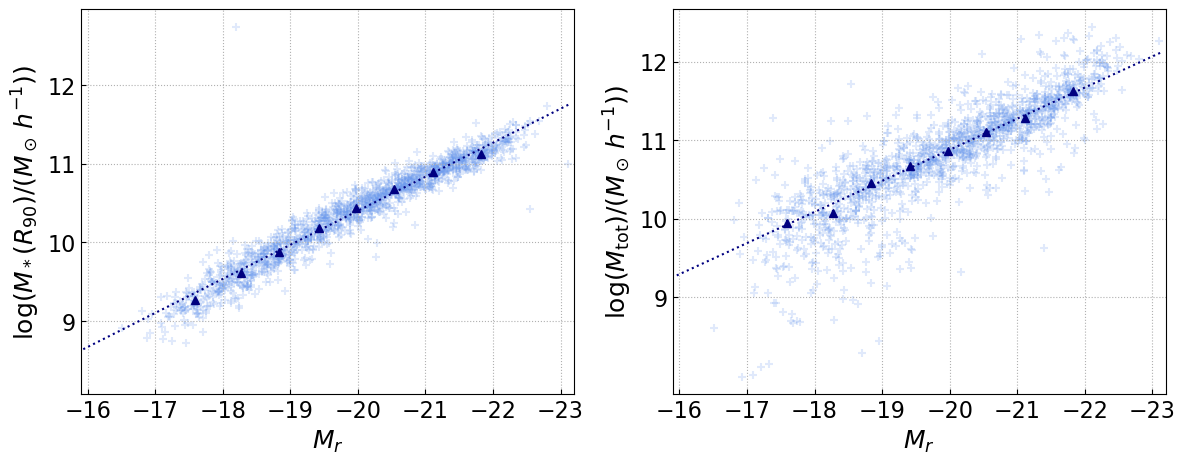

In [18]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(green_spirals['rabsmag'], green_spirals['M90_disk_h'], marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(gs_mr_ctrs, gs_mstar_avg, yerr=gs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(gs_mr_ctrs, gs_mtot_avg, yerr=gs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*gs_mstar_popt[0] + gs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*gs_mtot_popt[0] + gs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### red spiral

In [20]:
rs_mr_ctrs = []
rs_mstar = []
rs_mtot = []
rs_mr_bins=mr_bins
rs_mr_bins = np.concatenate((mr_bins[:1], mr_bins[4:-7], mr_bins[-1:]))

indices = np.digitize(red_spirals['rabsmag'], rs_mr_bins, right=True)

for i in range(1,len(rs_mr_bins)):

    rs_mstar.append(red_spirals['M90_disk_h'][indices==i])
    rs_mtot.append(red_spirals['M_R90'][indices==i])
    rs_mr_ctrs.append(np.mean(red_spirals['rabsmag'][indices==i]))

rs_mstar_avg, rs_mstar_sig = fit_to_gaussian(rs_mstar, plot_dir = plot_dir + '/rs_mr/', plot_name='rs_Mstar90_Mr', xlab=r'$M_*$')
rs_mtot_avg, rs_mtot_sig = fit_to_gaussian(rs_mtot, plot_dir = plot_dir + '/rs_mr/', plot_name='rs_Mtot_Mr', xlab=r'$M_{\rm tot}$')

# fit da lines

rs_mstar_popt, rs_mstar_pcov = curve_fit(lin_fit, rs_mr_ctrs, 
                                       rs_mstar_avg, sigma=rs_mstar_sig)
rs_mtot_popt, rs_mtot_pcov = curve_fit(lin_fit, rs_mr_ctrs, 
                                       rs_mtot_avg, sigma=rs_mtot_sig)

print(rs_mstar_popt, np.sqrt(rs_mstar_pcov[0,0]), np.sqrt(rs_mstar_pcov[1,1]))
print(rs_mtot_popt, np.sqrt(rs_mtot_pcov[0,0]), np.sqrt(rs_mtot_pcov[1,1]))

[-0.41733493  2.09717863] 0.019918028912753984 0.4028146451294794
[-0.41997128  2.45239955] 0.019270386829373064 0.38798062068583405


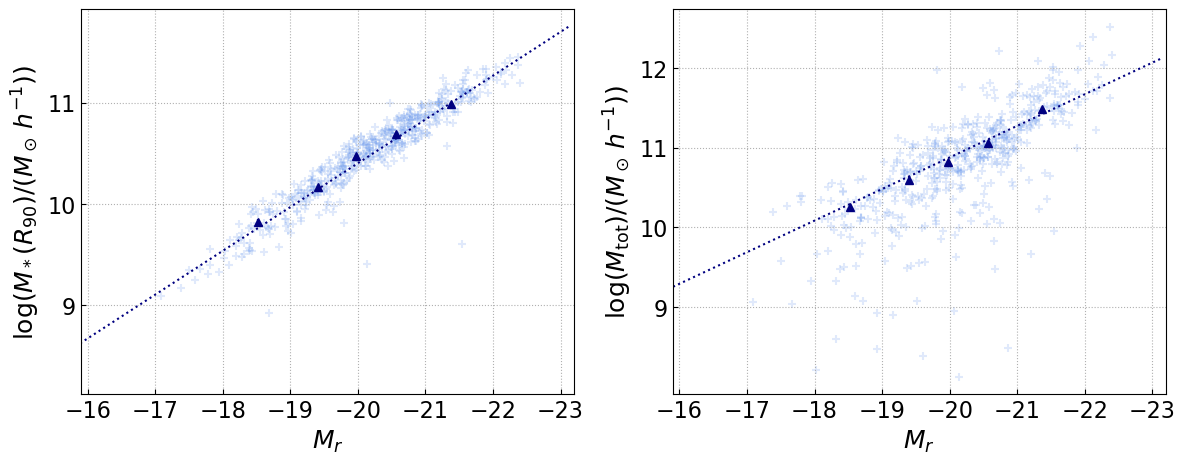

In [21]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].scatter(red_spirals['rabsmag'], red_spirals['M90_disk_h'], marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], marker='+', color='cornflowerblue', alpha=0.2)
ax[0].errorbar(rs_mr_ctrs, rs_mstar_avg, yerr=rs_mstar_sig, color='navy', linestyle='none', marker='^')
ax[1].errorbar(rs_mr_ctrs, rs_mtot_avg, yerr=rs_mtot_sig, color='navy', linestyle='none', marker='^')
ax[0].set_yticks(np.arange(9,13,1))
ax[1].set_yticks(np.arange(9,14,1))
ax[0].set_ylabel(r'$\log(M_*(R_{90})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[1].set_ylabel(r'$\log(M_{\rm tot})/(M_\odot\,h^{-1}))$', fontsize=18)
ax[0].plot(mr_bins, mr_bins*gs_mstar_popt[0] + gs_mstar_popt[1], linestyle=':', color='navy')
ax[1].plot(mr_bins, mr_bins*gs_mtot_popt[0] + gs_mtot_popt[1], linestyle=':', color='navy')


for i in range(2):
    ax[i].set_xlim(-15.9,-23.2)
    ax[i].set_xlabel(r'$M_r$', fontsize=18)
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')
    ax[i].set_xticks(np.arange(-23,-15,1))


fig.subplots_adjust(wspace=0.2, hspace=0.05)


#### combine all

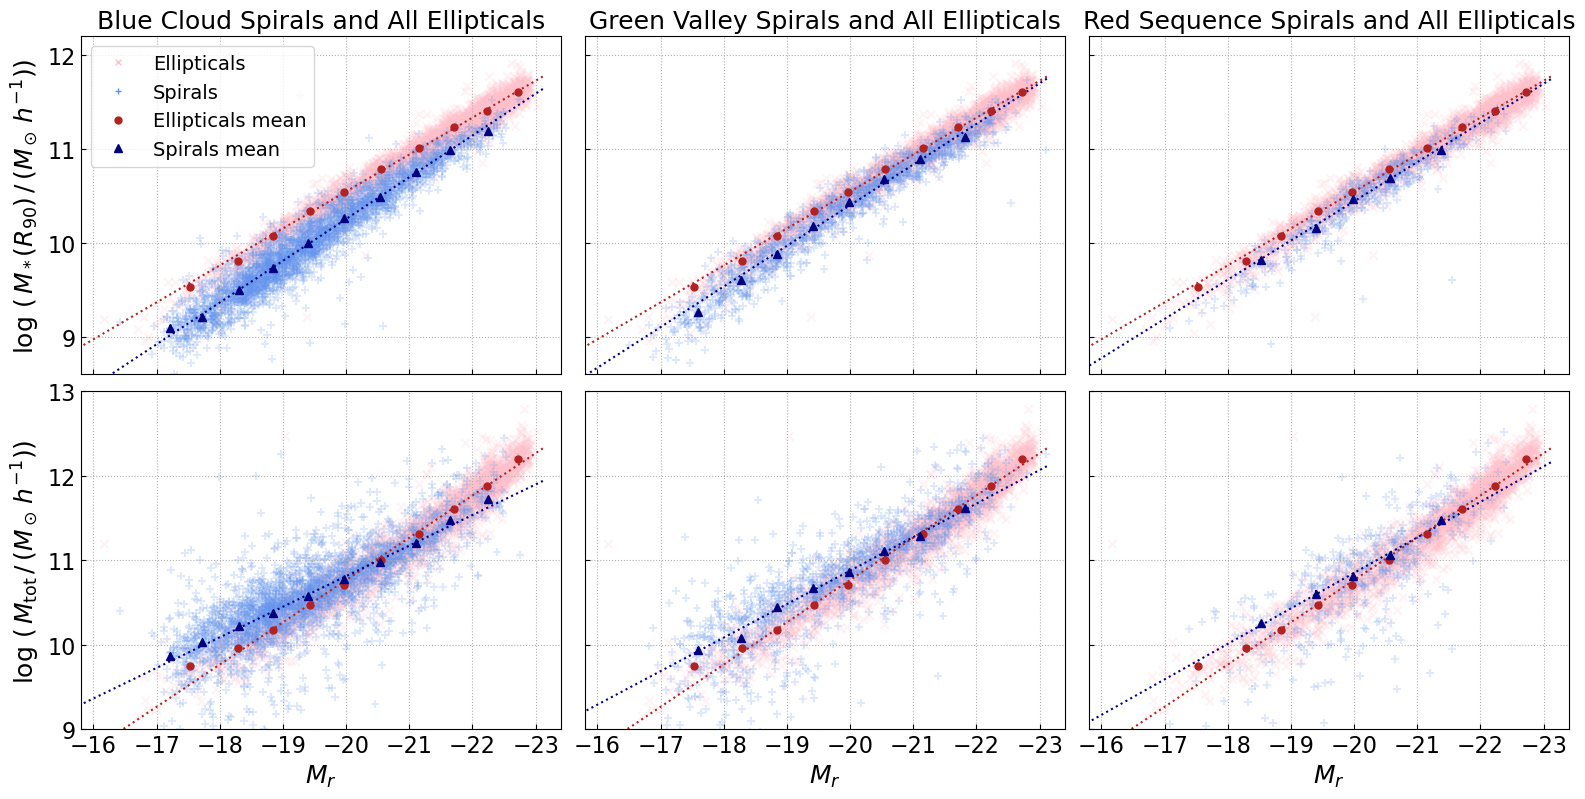

In [22]:
fig, ax = plt.subplots(2,3,sharex=True, sharey='row', figsize=(19.2,9))

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)

ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
rs = np.linspace(-23.2,-17.2,100)


for i in range(0,2):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[1,i].set_xlabel(r'$M_r$', fontsize=18)
    
    ax[1,i].set_xticks(np.arange(-23,-15,1))
    ax[1,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_ctrs, e_mstar_avg, color='firebrick', yerr=e_mstar_sig, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mr_bins, e_mstar_popt[0]*mr_bins + e_mstar_popt[1], color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_ctrs,e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
                 marker='o',linestyle='none', markersize=5, )
    ax[1,i].plot(mr_bins, e_mtot_popt[0]*mr_bins + e_mtot_popt[1], color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_spirals['rabsmag'], blue_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_ctrs, bs_mstar_avg, color='navy', yerr=bs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mr_bins, bs_mstar_popt[0]*mr_bins + bs_mstar_popt[1], color='navy', linestyle=':')




ax[0,1].scatter(green_spirals['rabsmag'], green_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_ctrs, gs_mstar_avg, color='navy', yerr=gs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mr_bins, gs_mstar_popt[0]*mr_bins + gs_mstar_popt[1], color='navy', linestyle=':')





ax[0,2].scatter(red_spirals['rabsmag'], red_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_ctrs,rs_mstar_avg, color='navy', yerr=rs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mr_bins, rs_mstar_popt[0]*mr_bins + rs_mstar_popt[1], color='navy', linestyle=':')



ax[1,0].scatter(blue_spirals['rabsmag'], blue_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,0].errorbar(bs_mr_ctrs, bs_mtot_avg, color='navy', yerr=bs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,0].plot(mr_bins, bs_mtot_popt[0]*mr_bins + bs_mtot_popt[1], color='navy', linestyle=':')



ax[1,1].scatter(green_spirals['rabsmag'], green_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[1,1].errorbar(gs_mr_ctrs, gs_mtot_avg, color='navy', yerr=gs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[1,1].plot(mr_bins, gs_mtot_popt[0]*mr_bins + gs_mtot_popt[1], color='navy', linestyle=':')



ax[1,2].scatter(red_spirals['rabsmag'], red_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ax[1,2].errorbar(rs_mr_ctrs, rs_mtot_avg, color='navy', yerr=rs_mtot_sig, 
                 marker='^', label='red sequence spiral median',linestyle='none', markersize=6,)
ax[1,2].plot(mr_bins, rs_mtot_popt[0]*mr_bins + rs_mtot_popt[1], color='navy', linestyle=':')

fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig(plot_dir + 'paper_plots/Mtot_Mstar_Mr_CMDspiral_ellipticals.png', bbox_inches='tight')

## mtot vs mvis

In [23]:
HI_spirals = spirals[spirals['logHI']>0]
HI_spirals['Mstar_MHI_h'] = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'])

### hi (obs) + mstar vs mtot

In [34]:
mvis_bins = np.linspace(np.min([np.min(HI_spirals['Mstar_MHI_h']), np.min(ellipticals['sphd_M_star_h'])])-0.01,
                  12.5, 15)

#### ellipticals

In [35]:
# ellipticals
e_mvis_ctrs = []
e_mtot = []
# e_mvis_bins = mvis_bins
e_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[4:-3], mvis_bins[-1:]))

indices = np.digitize(ellipticals['sphd_M_star_h'], e_mvis_bins, right=True)

for i in range(1,len(e_mvis_bins)):
    
    e_mtot.append(ellipticals['Mvir'][indices==i])
    e_mvis_ctrs.append(np.mean(ellipticals['sphd_M_star_h'][indices==i]))


e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + '/e_mtot_mvis/', plot_name='e_Mtot_Mvis', xlab=r'$M_{\rm tot}$')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mvis_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[ 1.24028186 -2.37281562] 0.03568830404240824 0.3924882930634304


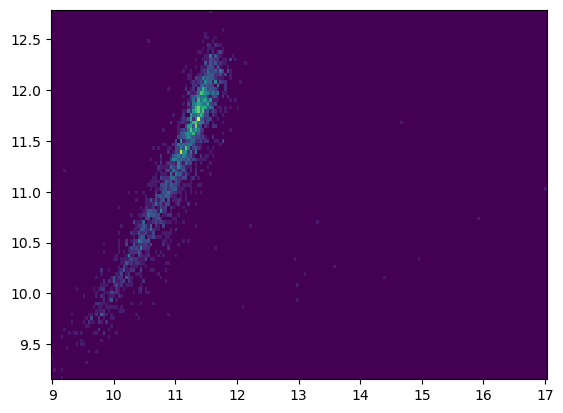

In [36]:
h,xs,ys,im  = plt.hist2d(ellipticals['sphd_M_star_h'], ellipticals['Mvir'], bins=(200,100))

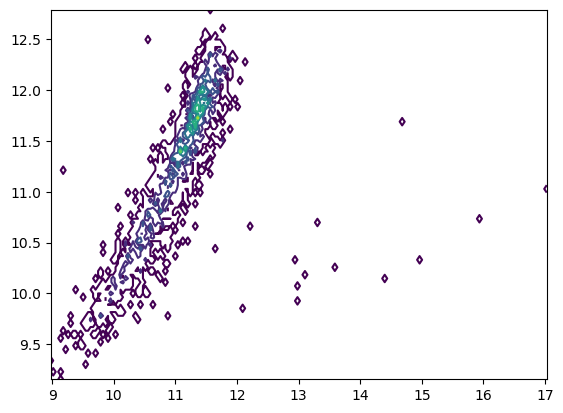

In [37]:
# X,Y = np.meshgrid((xs[1:]+ xs[:-1])/2, (ys[1:] + ys[:-1])/2)
plt.contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()],
            )

(array([1.9475e+04, 1.9300e+02, 1.2100e+02, 8.1000e+01, 4.1000e+01,
        3.4000e+01, 1.9000e+01, 1.0000e+01, 7.0000e+00, 9.0000e+00,
        5.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]),
 array([ 0.        ,  1.05263158,  2.10526316,  3.15789474,  4.21052632,
         5.26315789,  6.31578947,  7.36842105,  8.42105263,  9.47368421,
        10.52631579, 11.57894737, 12.63157895, 13.68421053, 14.73684211,
        15.78947368, 16.84210526, 17.89473684, 18.94736842, 20.        ]),
 <BarContainer object of 19 artists>)

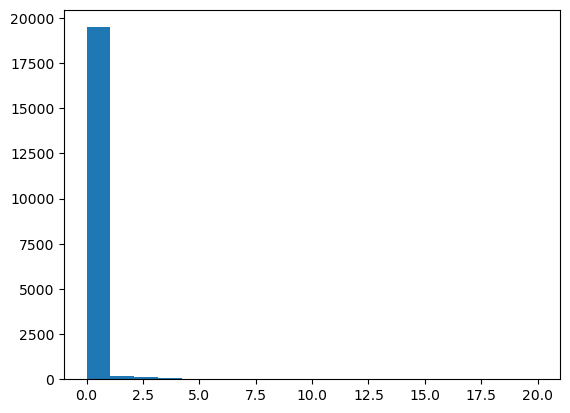

In [38]:
plt.hist(h.flat, bins=np.linspace(0,20,20))

In [39]:
np.max(h)

15.0

In [40]:
np.linspace(1,15,6)

array([ 1. ,  3.8,  6.6,  9.4, 12.2, 15. ])

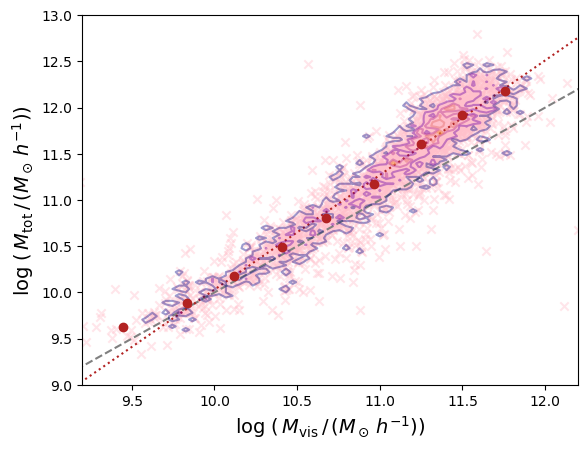

In [42]:
plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.4)
plt.errorbar(e_mvis_ctrs, e_mtot_avg, yerr=e_mtot_sig, marker='o', color='firebrick', linestyle='none')
plt.plot([8.5,13],[8.5,13], color='grey', linestyle='--')
plt.xlim(8.5, 13)
plt.plot(mvis_bins, mvis_bins*e_mtot_popt[0] + e_mtot_popt[1], linestyle=':', color='firebrick')
plt.contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()],levels=np.linspace(1,15,6), alpha=0.4, cmap='plasma')
plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.savefig(plot_dir + 'e_mvis_mtot_contour.png')

#### spirals 

In [44]:
s_mvis_ctrs = []
s_mtot = []
s_mvis_bins = mvis_bins

s_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))

indices = np.digitize(HI_spirals['Mstar_MHI_h'], s_mvis_bins, right=True)

for i in range(1,len(s_mvis_bins)):
    
    s_mtot.append(HI_spirals['M_R90'][indices==i])
    s_mvis_ctrs.append(np.mean(HI_spirals['Mstar_MHI_h'][indices==i]))


s_mtot_avg, s_mtot_sig = fit_to_gaussian(s_mtot, plot_dir = plot_dir + '/s_Mtot_MstarHIobs/', plot_name='s_Mtot_MstarHIobs', xlab=r'$M_{\rm tot}$')

# fit da lines

s_mtot_popt, s_mtot_pcov = curve_fit(lin_fit, s_mvis_ctrs, 
                                       s_mtot_avg, sigma=s_mtot_sig)

print(s_mtot_popt, np.sqrt(s_mtot_pcov[0,0]), np.sqrt(s_mtot_pcov[1,1]))

[0.81186023 2.3599508 ] 0.0348748045481558 0.3558450545135619


Text(0, 0.5, '$\\log(M_{\\rm tot}/(M_\\odot h^{-1})$')

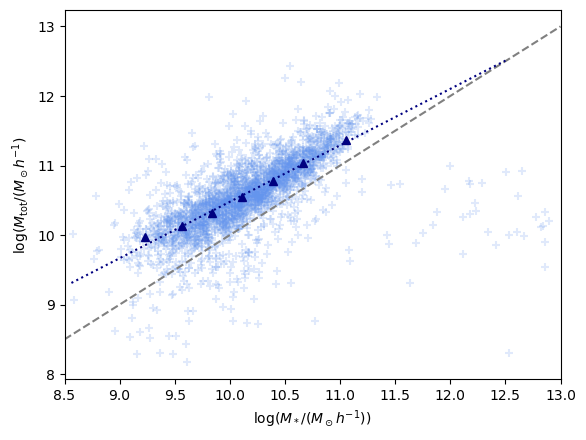

In [45]:
plt.scatter(HI_spirals['Mstar_MHI_h'], HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2)
plt.errorbar(s_mvis_ctrs, s_mtot_avg, yerr=s_mtot_sig, marker='^', color='navy', linestyle='none')
plt.plot([8.5,13],[8.5,13], color='grey', linestyle='--')
plt.xlim(8.5, 13)
plt.plot(mvis_bins, mvis_bins*s_mtot_popt[0] + s_mtot_popt[1], linestyle=':', color='navy')
plt.xlabel(r'$\log(M_*/(M_\odot h^{-1}))$')
plt.ylabel(r'$\log(M_{\rm tot}/(M_\odot h^{-1})$')

#### combine

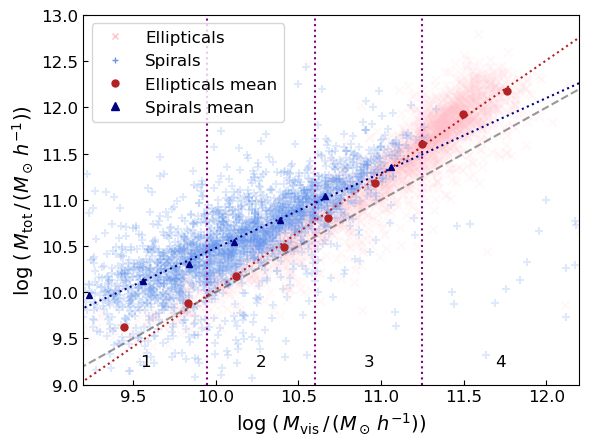

In [46]:
plt.axvline(9.95, color='purple', alpha=1, linestyle=':')
plt.axvline(10.6, color='purple', alpha=1,linestyle=':')
plt.axvline(11.25, color='purple', alpha=1,linestyle=':')

plt.scatter(ellipticals['sphd_M_star_h'], ellipticals['Mvir'], color='pink', alpha=0.1, marker='x')
plt.scatter(HI_spirals['Mstar_MHI_h'], HI_spirals['M_R90'], 
            color='cornflowerblue', alpha=0.2, marker='+')


plt.xlabel(r'$\log\,(\,M_{\rm vis}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
plt.xlim(9.2,12.2)
plt.ylim(9,13)
plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
# plt.title('Elliptical and spiral galaxy total masses')
plt.tick_params( axis='both', direction='in',labelsize=12)
plt.plot([9,13],[9,13], color='k', linestyle='--', alpha=0.4)

plt.plot(mvis_bins, mvis_bins*e_mtot_popt[0] + e_mtot_popt[1], color='firebrick', linestyle=':')
plt.plot(mvis_bins, mvis_bins*s_mtot_popt[0] + s_mtot_popt[1], color='navy', linestyle=':')


plt.errorbar(e_mvis_ctrs, e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
             marker='o',linestyle='none', markersize=5, )


plt.errorbar(s_mvis_ctrs, s_mtot_avg, color='navy', yerr=s_mtot_sig, 
             marker='^',linestyle='none', markersize=5, )


legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


plt.legend(handles=legend_elements,fontsize=12)


plt.text((9.2+9.95)/2,9.2,'1', fontsize=12, ha='center')
plt.text((9.95+10.6)/2,9.2,'2', fontsize=12,ha='center')
plt.text((10.6 + 11.25)/2,9.2,'3', fontsize=12,ha='center')
plt.text((11.25+12.2)/2,9.2,'4', fontsize=12,ha='center')

plt.savefig(plot_dir + 'paper_plots/Mvis_Mtot_ellipticals_median.png')

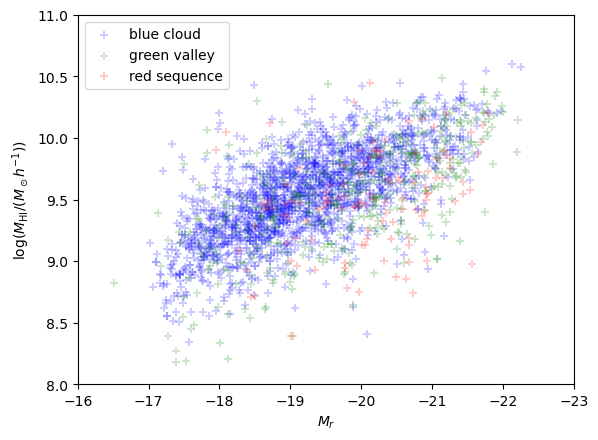

In [29]:
plt.scatter(blue_spirals['rabsmag'], blue_spirals['logHI']+np.log10(0.7), marker='+', color='b', alpha=0.2, label='blue cloud')
plt.scatter(green_spirals['rabsmag'], green_spirals['logHI']+np.log10(0.7), marker='+', color='g', alpha=0.2, label='green valley')
plt.scatter(red_spirals['rabsmag'], red_spirals['logHI']+np.log10(0.7), marker='+', color='r', alpha=0.2, label='red sequence')
plt.xlim(-16,-23)
plt.ylim(8,11)
plt.legend()
plt.ylabel(r'$\log(M_{\rm HI}/ (M_\odot h^{-1}))$')
plt.xlabel(r'$M_r$')
plt.savefig(plot_dir + 'paper_plots/Mr_HI.png')

## BPT

In [47]:
BPT_dict = {1.0: 'slateblue',
            2.0: 'limegreen',
            3.0:'lightcoral',
            0: 'k',}

BPT_m_dict = {1.0: 's',
              2.0: '^',
              3.0: 'o',
             0: '.'}
BPT_s_dict = {1.0: 5,
              2.0: 10,
              3.0: 10,
             0: 1}

def dust_corr(Ha, Hb, N2, O3, corr_law='CCM89'):
    
    rc= pn.RedCorr(law=corr_law)

    H_ratio = Ha/Hb

    rc.setCorr(H_ratio / 2.86, 6562, 4861)

    # in order Ha, Hb, NII, OIII
    wavelengths = np.array([6562, 4861, 6583, 5006])
    corr = rc.getCorrHb(wavelengths)

    Ha_corr = Ha * corr[0]
    Hb_corr = Hb * corr[1]
    N2_corr = N2 * corr[2]
    O3_corr = O3 * corr[3]

    return Ha_corr, Hb_corr, N2_corr, O3_corr

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_7428/4163645990.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  H_ratio = Ha/Hb
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:252: RuntimeWarning: invalid value encountered in divide
  return np.squeeze(10. ** (0.4 * np.outer(X, self.E_BV).reshape(X.shape + self.E_BV.shape))) / rel_corr
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:316: RuntimeWarning: divide by zero encountered in log10
  self.E_BV = 2.5 * np.log10(obs_over_theo) / (f1 - f2)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_7428/3197918023.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(N2/Ha),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_7428/3197918023.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(O3/Hb),
/var/folders/4q/zk1xkb454t7_ncsh3pf

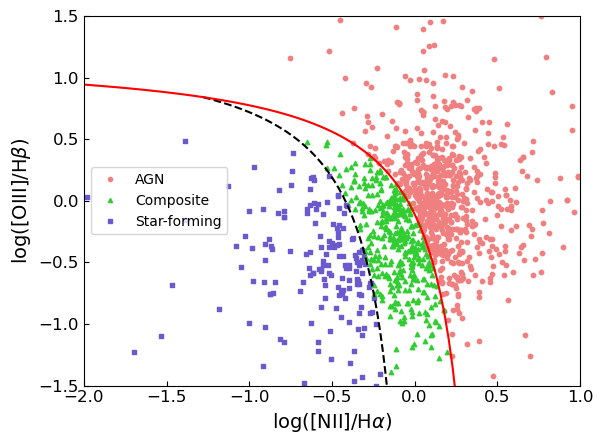

In [51]:
for i in range(len(ellipticals)):
    
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]


    Ha, Hb, N2, O3 = dust_corr(nsa_portsmouth['Flux_Ha_6562'][nsa_idx], nsa_portsmouth['Flux_Hb_4861'][nsa_idx],
                               nsa_portsmouth['Flux_NII_6583'][nsa_idx], nsa_portsmouth['Flux_OIII_5006'][nsa_idx])

    plt.scatter(np.log10(N2/Ha),
                    np.log10(O3/Hb),
                    marker=BPT_m_dict[ellipticals[i]['BPT_class']], color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=1, s=BPT_s_dict[ellipticals[i]['BPT_class']]
               )

plt.xlim(-2,1)
plt.ylim(-1.5,1.5)

x = np.linspace(-1.28,0,100)
plt.plot(x,0.61/(x-0.05) + 1.3, color='k', linestyle='--')
x1 = np.linspace(-2,0.4,100)
plt.plot(x1,0.61/(x1 - 0.47) + 1.19, color='r')

plt.xlabel(r'log([NII]/H$\alpha$)', fontsize=14)
plt.ylabel(r'log([OIII]/H$\beta$)', fontsize=14)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3)]
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.legend(handles=legend_elements)
# plt.savefig(plot_dir + 'ellipticals_BPT.png', bbox_inches='tight')

In [52]:
u_ellipticals = ellipticals[ellipticals['BPT_class']==0]
sf_ellipticals = ellipticals[ellipticals['BPT_class']==1]
c_ellipticals = ellipticals[ellipticals['BPT_class']==2]
agn_ellipticals = ellipticals[ellipticals['BPT_class']==3]

In [53]:
bins = np.array([np.min(ellipticals['sphd_M_star_h'])-0.01,9.95,10.6,11.25,np.max(ellipticals['sphd_M_star_h'])])


#### all ellipticals

In [54]:
ellipticals_mtot_mstar = 10**(ellipticals['Mvir'] - (ellipticals['sphd_M_star_h']))
agn_ellipticals_mtot_mstar = 10**(agn_ellipticals['Mvir'] - (agn_ellipticals['sphd_M_star_h']))
c_ellipticals_mtot_mstar = 10**(c_ellipticals['Mvir'] - (c_ellipticals['sphd_M_star_h']))
sf_ellipticals_mtot_mstar = 10**(sf_ellipticals['Mvir'] - (sf_ellipticals['sphd_M_star_h']))

In [57]:
all_mtot = []
all_mtot_mstar = []
all_ctr = []

all_bins = bins

indices = np.digitize(ellipticals['sphd_M_star_h'], bins, right=True)

for i in range(1, len(bins)):
    all_mtot.append(ellipticals['Mvir'][indices==i])
    all_ctr.append(np.mean(ellipticals['sphd_M_star_h'][indices==i]))
    all_mtot_mstar.append(ellipticals_mtot_mstar[indices==i])


all_mtot_mstar_avg, all_mtot_mstar_sig = fit_to_gaussian(all_mtot_mstar, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                                        use_custom_bins=True,
                                                        custom_bins=[np.concatenate((np.linspace(0,4,10), np.array([101,103]))),
                                                                     np.concatenate((np.linspace(0,6,20), np.array([80,82]))),
                                                                     33,
                                                                     33])
all_mtot_avg, all_mtot_sig = fit_to_gaussian(all_mtot, plot_dir = plot_dir+ '/BPT/', 
                                                         plot_name='all_ellipticals_Mtot', xlab=r'$M_{\rm tot}$')

In [58]:
all_mtot_mstar_sig

array([-0.03505294, -0.02204808,  0.02609068,  0.03298358])

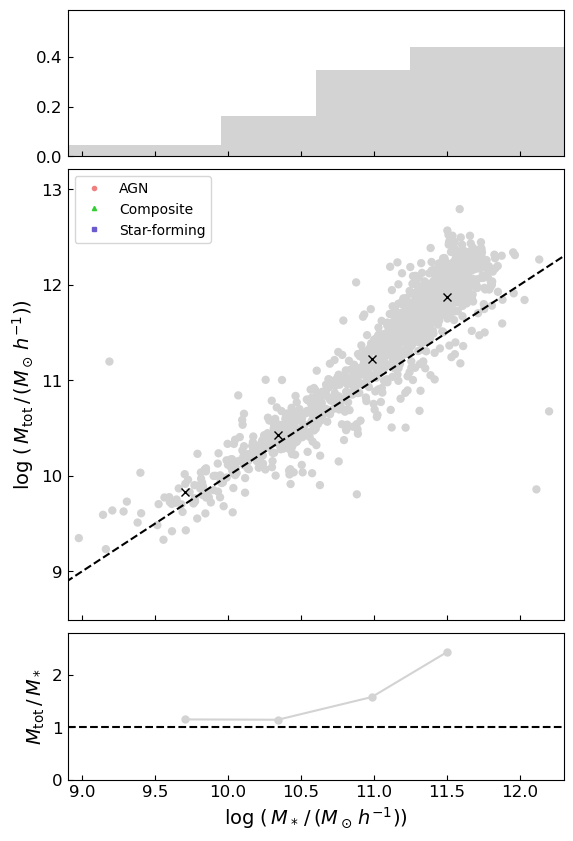

In [59]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], [8.7,9.95,10.6,11.25,13], 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         


ax[1].scatter(u_ellipticals['sphd_M_star_h'], u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)

ax[1].errorbar(all_ctr, all_mtot_avg, yerr=np.abs(all_mtot_sig), marker='x', color='k', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=np.abs(all_mtot_mstar_sig), 
             marker='o', markersize=5, )



ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)

#### sf ellipticals

In [60]:
sf_mtot = []
sf_mtot_mstar = []
sf_ctr = []
sf_bins=bins
sf_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(sf_ellipticals['sphd_M_star_h'], sf_bins, right=True)

for i in range(1, len(sf_bins)):
    sf_mtot.append(sf_ellipticals['Mvir'][indices==i])
    sf_ctr.append(np.mean(sf_ellipticals['sphd_M_star_h'][indices==i]))
    sf_mtot_mstar.append(sf_ellipticals_mtot_mstar[indices==i])


sf_mtot_mstar_avg, sf_mtot_mstar_sig = fit_to_gaussian(sf_mtot_mstar, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='sf_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                                       use_custom_bins=True,
                                                       custom_bins=[np.concatenate((np.linspace(0,5,7), np.array([80,82]))),
                                                                    8,
                                                                    8]
                                                      )
sf_mtot_avg, sf_mtot_sig = fit_to_gaussian(sf_mtot, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='sf__ellipticals_Mtot', xlab=r'$M_{\rm tot}$')

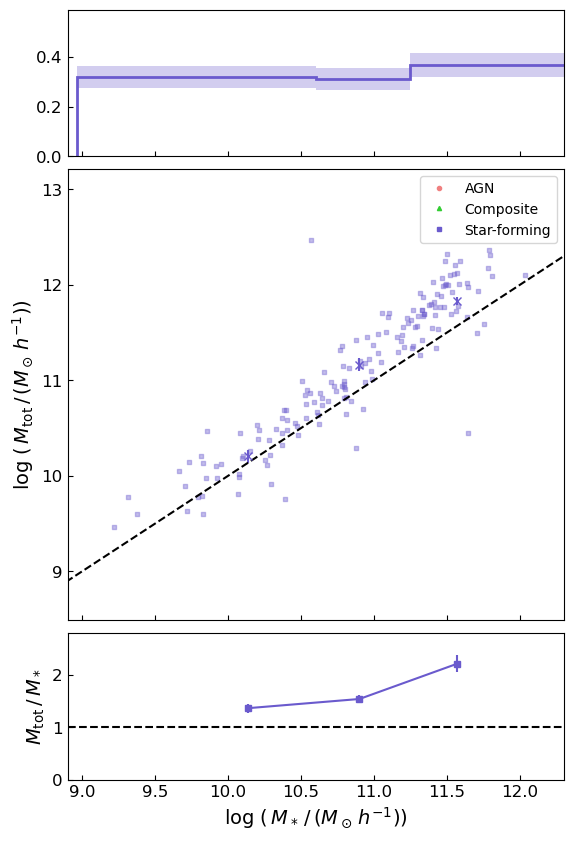

In [61]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(sf_mtot[0])/len(sf_ellipticals),len(sf_mtot[1])/len(sf_ellipticals),
              len(sf_mtot[2])/len(sf_ellipticals)], sf_bins,
             color='slateblue', alpha=1, label=r'sf', lw=2)

ax[0].stairs([(len(sf_mtot[0])+np.sqrt(len(sf_mtot[0])))/len(sf_ellipticals),
              (len(sf_mtot[1])+np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])+np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)], 
                sf_bins,
                baseline=[(len(sf_mtot[0])-np.sqrt(len(sf_mtot[0])))/len(sf_ellipticals),
              (len(sf_mtot[1])-np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])-np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)





ax[1].scatter(sf_ellipticals['sphd_M_star_h'], sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)


ax[1].errorbar(sf_ctr, sf_mtot_avg, yerr=sf_mtot_sig, marker='x', color='slateblue', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)


ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(sf_ctr, sf_mtot_mstar_avg, color='slateblue', yerr=np.abs(sf_mtot_mstar_sig), 
             marker='s', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)


#### c ellipticals

In [62]:
c_mtot = []
c_mtot_mstar = []
c_ctr = []
c_bins=bins
# c_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(c_ellipticals['sphd_M_star_h'], c_bins, right=True)

for i in range(1, len(c_bins)):
    c_mtot.append(c_ellipticals['Mvir'][indices==i])
    c_ctr.append(np.mean(c_ellipticals['sphd_M_star_h'][indices==i]))
    c_mtot_mstar.append(c_ellipticals_mtot_mstar[indices==i])


c_mtot_mstar_avg, c_mtot_mstar_sig = fit_to_gaussian(c_mtot_mstar, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='c_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot}$')
c_mtot_avg, c_mtot_sig = fit_to_gaussian(c_mtot, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='c__ellipticals_Mtot', xlab=r'$M_{\rm tot}$')

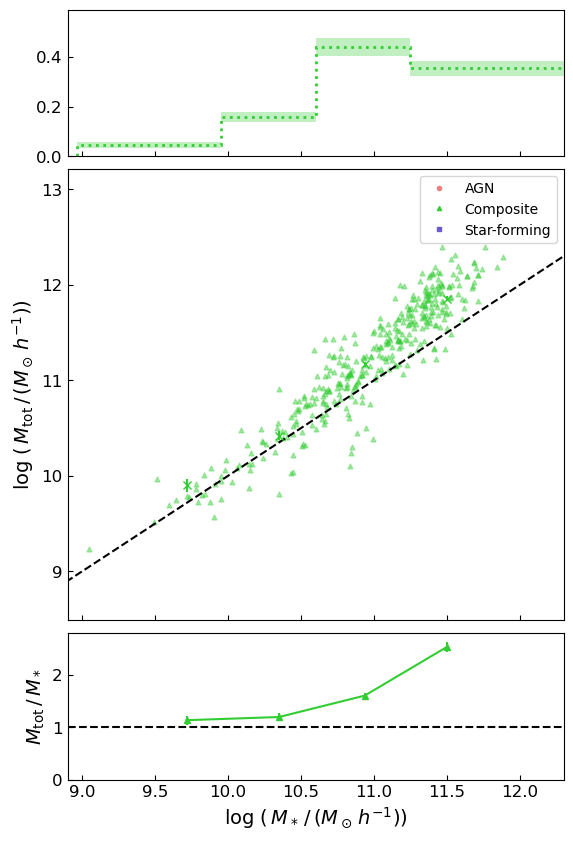

In [63]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(c_mtot[0])/len(c_ellipticals),
              len(c_mtot[1])/len(c_ellipticals),
              len(c_mtot[2])/len(c_ellipticals),
              len(c_mtot[3])/len(c_ellipticals)], 
              c_bins,
             color='limegreen', alpha=1, label=r'sf', linestyle=':',lw=2)

ax[0].stairs([(len(c_mtot[0])+np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
              (len(c_mtot[1])+np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
              (len(c_mtot[2])+np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
              (len(c_mtot[3])+np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             c_bins,
             baseline=[
                 (len(c_mtot[0])-np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
                 (len(c_mtot[1])-np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
                 (len(c_mtot[2])-np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
                 (len(c_mtot[3])-np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)






ax[1].scatter(c_ellipticals['sphd_M_star_h'], c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)


ax[1].errorbar(c_ctr, c_mtot_avg, yerr=c_mtot_sig, marker='x', color='limegreen', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)


ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(c_ctr, c_mtot_mstar_avg, color='limegreen', yerr=c_mtot_mstar_sig, 
             marker='^', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
# plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

#### agn ellipticals

In [64]:
agn_mtot = []
agn_mtot_mstar = []
agn_ctr = []
agn_bins=bins
agn_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(agn_ellipticals['sphd_M_star_h'], agn_bins, right=True)

for i in range(1, len(agn_bins)):
    agn_mtot.append(agn_ellipticals['Mvir'][indices==i])
    agn_ctr.append(np.mean(agn_ellipticals['sphd_M_star_h'][indices==i]))
    agn_mtot_mstar.append(agn_ellipticals_mtot_mstar[indices==i])


agn_mtot_mstar_avg, agn_mtot_mstar_sig = fit_to_gaussian(agn_mtot_mstar, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='agn_ellipticals_Mtot_Mstar', xlab=r'$M_{\rm tot}$')
agn_mtot_avg, agn_mtot_sig = fit_to_gaussian(agn_mtot, plot_dir = plot_dir + '/BPT/', 
                                                         plot_name='agn_ellipticals_Mtot', xlab=r'$M_{\rm tot}$')

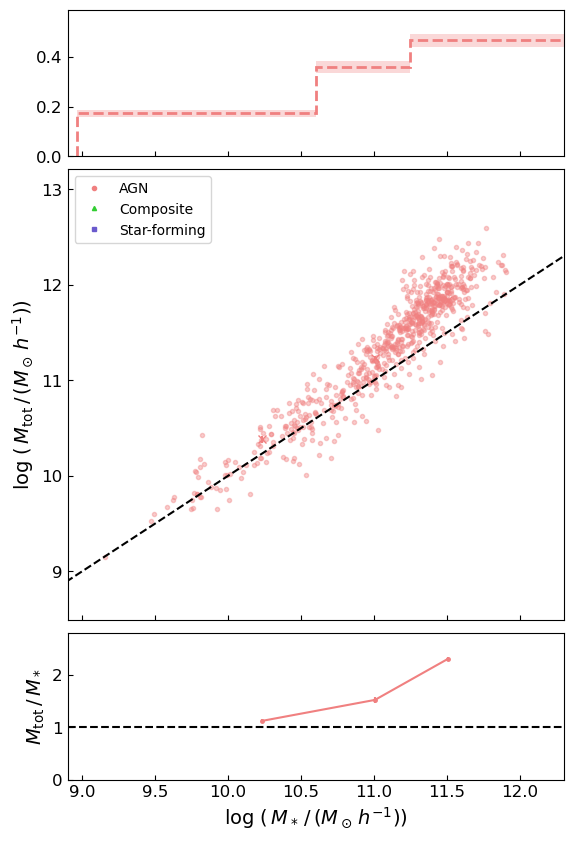

In [65]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(agn_mtot[0])/len(agn_ellipticals),
              len(agn_mtot[1])/len(agn_ellipticals),
              len(agn_mtot[2])/len(agn_ellipticals)], agn_bins,
             color='lightcoral', alpha=1, label=r'sf', linestyle='--', lw=2)


ax[0].stairs([(len(agn_mtot[0])+np.sqrt(len(agn_mtot[0])))/len(agn_ellipticals),
              (len(agn_mtot[1])+np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])+np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)], 
                agn_bins,
                baseline=[(len(agn_mtot[0])-np.sqrt(len(agn_mtot[0])))/len(agn_ellipticals),
              (len(agn_mtot[1])-np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])-np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




ax[1].scatter(agn_ellipticals['sphd_M_star']+np.log10(0.73), agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)


ax[1].errorbar(agn_ctr, agn_mtot_avg, yerr=agn_mtot_sig, marker='x', color='lightcoral', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(agn_ctr, agn_mtot_mstar_avg, color='lightcoral', yerr=agn_mtot_mstar_sig, 
             marker='.', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
# plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

#### combine

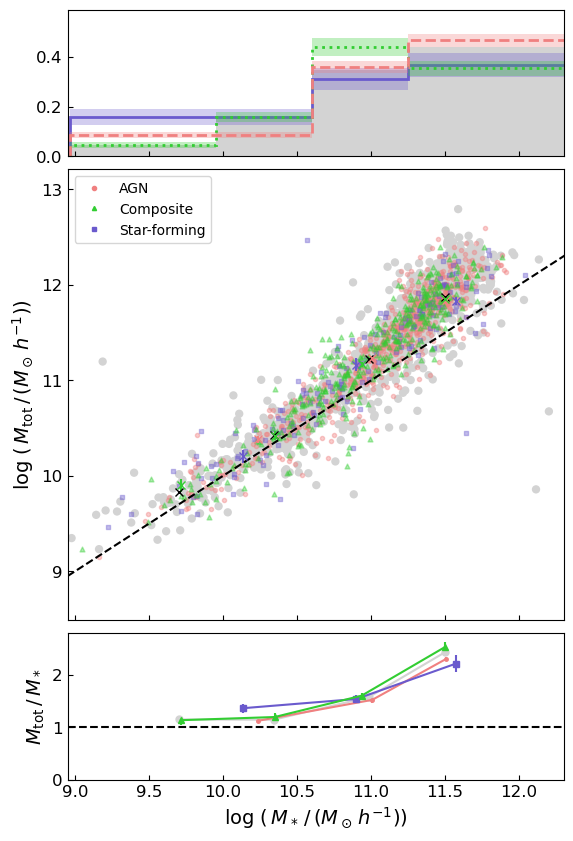

In [66]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], all_bins, 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(sf_mtot[0])/ 2 / len(sf_ellipticals),len(sf_mtot[1])/len(sf_ellipticals),
              len(sf_mtot[2])/len(sf_ellipticals)], sf_bins,
             color='slateblue', alpha=1, lw=2)

ax[0].stairs([(len(sf_mtot[0])/2+np.sqrt(len(sf_mtot[0])/2))/len(sf_ellipticals),
              (len(sf_mtot[1])+np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])+np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)], 
                sf_bins,
                baseline=[(len(sf_mtot[0])/2-np.sqrt(len(sf_mtot[0])/2))/len(sf_ellipticals),
              (len(sf_mtot[1])-np.sqrt(len(sf_mtot[1])))/len(sf_ellipticals),
              (len(sf_mtot[2])-np.sqrt(len(sf_mtot[2])))/len(sf_ellipticals)],
             color='slateblue', alpha=0.3, lw=2, fill=True)

ax[0].stairs([len(c_mtot[0])/len(c_ellipticals),
              len(c_mtot[1])/len(c_ellipticals),
              len(c_mtot[2])/len(c_ellipticals),
              len(c_mtot[3])/len(c_ellipticals)], 
              c_bins,
             color='limegreen', alpha=1, linestyle=':',lw=2)

ax[0].stairs([(len(c_mtot[0])+np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
              (len(c_mtot[1])+np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
              (len(c_mtot[2])+np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
              (len(c_mtot[3])+np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             c_bins,
             baseline=[
                 (len(c_mtot[0])-np.sqrt(len(c_mtot[0])))/len(c_ellipticals),
                 (len(c_mtot[1])-np.sqrt(len(c_mtot[1])))/len(c_ellipticals),
                 (len(c_mtot[2])-np.sqrt(len(c_mtot[2])))/len(c_ellipticals),
                 (len(c_mtot[3])-np.sqrt(len(c_mtot[3])))/len(c_ellipticals)],
             color='limegreen', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[0].stairs([len(agn_mtot[0])/2 / len(agn_ellipticals),
              len(agn_mtot[1])/len(agn_ellipticals),
              len(agn_mtot[2])/len(agn_ellipticals)],
             agn_bins,
             color='lightcoral', alpha=1, linestyle='--', lw=2)


ax[0].stairs([(len(agn_mtot[0])/2+np.sqrt(len(agn_mtot[0])/2))/len(agn_ellipticals),
              (len(agn_mtot[1])+np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])+np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)], 
             agn_bins,
                baseline=[(len(agn_mtot[0])/2-np.sqrt(len(agn_mtot[0])/2))/len(agn_ellipticals),
              (len(agn_mtot[1])-np.sqrt(len(agn_mtot[1])))/len(agn_ellipticals),
              (len(agn_mtot[2])-np.sqrt(len(agn_mtot[2])))/len(agn_ellipticals)],
             color='lightcoral', alpha=0.3, lw=2, fill=True)




ax[1].scatter(u_ellipticals['sphd_M_star_h'], u_ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(agn_ellipticals['sphd_M_star_h'], agn_ellipticals['Mvir'], color='lightcoral', marker='.', alpha=0.4)
ax[1].scatter(sf_ellipticals['sphd_M_star_h'], sf_ellipticals['Mvir'], color='slateblue', marker='s', alpha=0.4, s=8)
ax[1].scatter(c_ellipticals['sphd_M_star_h'], c_ellipticals['Mvir'], color='limegreen', marker='^', alpha=0.4, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(agn_ctr, agn_mtot_avg, yerr=agn_mtot_sig, marker='x', color='lightcoral', linestyle='none')
ax[1].errorbar(sf_ctr, sf_mtot_avg, yerr=sf_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(c_ctr, c_mtot_avg, yerr=c_mtot_sig, marker='x', color='limegreen', linestyle='none')

ax[1].set_xlim(8.95,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN',
                          markeredgecolor='lightcoral', mfc='lightcoral',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label='Composite',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='s', color='w', label='Star-forming',
                          markeredgecolor='slateblue', mfc='slateblue', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.59)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=np.abs(all_mtot_mstar_sig), 
             marker='o', markersize=5, )

ax[2].errorbar(agn_ctr, agn_mtot_mstar_avg, color='lightcoral', yerr=np.abs(agn_mtot_mstar_sig), 
             marker='.', markersize=5, )
ax[2].errorbar(sf_ctr, sf_mtot_mstar_avg, color='slateblue', yerr=np.abs(sf_mtot_mstar_sig), 
             marker='s', markersize=5, )
ax[2].errorbar(c_ctr, c_mtot_mstar_avg, color='limegreen', yerr=np.abs(c_mtot_mstar_sig), 
             marker='^', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_BPT_hist.png', bbox_inches='tight')

## metallicity

In [74]:
print(np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]))
print(np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]))

-0.528823407655138
0.187093875308831


(array([ 14.,  24.,  61.,  96., 187., 382., 611., 701., 320.,  55.]),
 array([-0.52882341, -0.45723168, -0.38563995, -0.31404822, -0.24245649,
        -0.17086477, -0.09927304, -0.02768131,  0.04391042,  0.11550215,
         0.18709388]),
 <BarContainer object of 10 artists>)

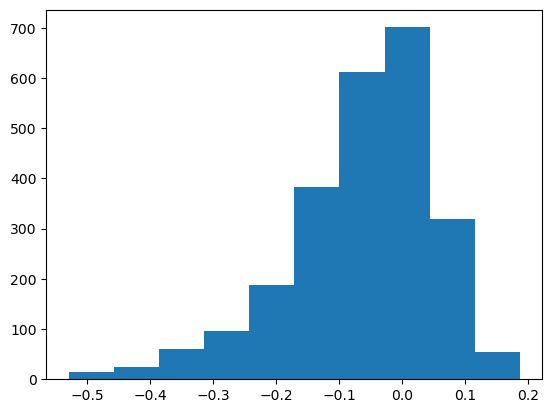

In [75]:
plt.hist(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])

In [76]:
counts, Zbins = np.histogram(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])
bin_ctrs = (Zbins[:-1] + Zbins[1:])/2
popt, pcov = curve_fit(gaussian, bin_ctrs, counts)
popt

array([ 6.91815843e+02, -3.43295267e-02,  9.64313276e-02])

In [77]:
z_bins = np.array([np.min(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99]-0.01),
                   popt[1]-popt[2], popt[1]+popt[2],
                     np.max(ellipticals['ZH_LW_Re_fit'][ellipticals['ZH_LW_Re_fit']>-99])])
good_z_ellipticals = ellipticals[ellipticals['ZH_LW_Re_fit']>-99]

z_indices = np.digitize(good_z_ellipticals['ZH_LW_Re_fit'], z_bins)

low_z = good_z_ellipticals[z_indices==1]
mid_z = good_z_ellipticals[z_indices==2]
high_z = good_z_ellipticals[z_indices==3]

low_z_ellipticals_mtot_mstar = 10**(low_z['Mvir'] - (low_z['sphd_M_star_h']))
mid_z_ellipticals_mtot_mstar = 10**(mid_z['Mvir'] - (mid_z['sphd_M_star_h']))
high_z_ellipticals_mtot_mstar = 10**(high_z['Mvir'] - (high_z['sphd_M_star_h']))



#### low z

In [78]:
low_z_mtot_mstar = []
low_z_mtot = []
low_z_ctr = []

low_z_bins = bins
# low_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(low_z['sphd_M_star_h'], low_z_bins)

for i in range(1, len(low_z_bins)):

    low_z_mtot.append(low_z['Mvir'][indices==i])
    low_z_mtot_mstar.append(low_z_ellipticals_mtot_mstar[indices==i])
    low_z_ctr.append(np.mean(low_z['sphd_M_star_h'][indices==i]))
    

low_z_mtot_mstar_avg, low_z_mtot_mstar_sig = fit_to_gaussian(low_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='low_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                            use_custom_bins=True,
                                                             custom_bins=[np.concatenate((np.linspace(0,4,10), np.array([101,103]))),
                                                                     np.concatenate((np.linspace(0,6,20), np.array([80,82]))),
                                                                     13,
                                                                     13]
                                                            )


low_z_mtot_avg, low_z_mtot_sig = fit_to_gaussian(low_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='low_z_Mtot', xlab=r'$M_{\rm tot}$')


low_z_mtot_popt, low_z_mtot_pcov = curve_fit(lin_fit, low_z_ctr, 
                                       low_z_mtot_avg, sigma=low_z_mtot_sig)

print(low_z_mtot_popt, np.sqrt(low_z_mtot_pcov[0,0]), np.sqrt(low_z_mtot_pcov[1,1]))


[ 1.21295758 -1.96425492] 0.06769152422813178 0.7286803469673957


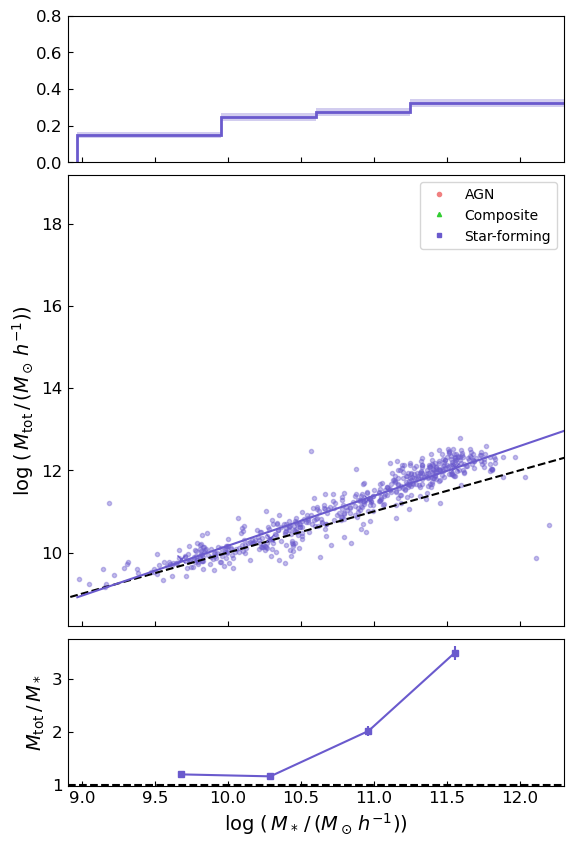

In [81]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
      
ax[0].stairs([len(low_z_mtot[0])/len(low_z),len(low_z_mtot[1])/len(low_z),
              len(low_z_mtot[2])/len(low_z), len(low_z_mtot[3])/len(low_z)], 
             low_z_bins,
             color='slateblue', alpha=1, label=r'low Z', lw=2)

ax[0].stairs([(len(low_z_mtot[0])+np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])+np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])+np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])+np.sqrt(len(low_z_mtot[3])))/len(low_z)], 
             low_z_bins,
                baseline=[(len(low_z_mtot[0])-np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])-np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])-np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])-np.sqrt(len(low_z_mtot[3])))/len(low_z)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[1].scatter(low_z['sphd_M_star_h'], low_z['Mvir'], color='slateblue', marker='.', alpha=0.4)

ax[1].errorbar(low_z_ctr, low_z_mtot_avg, yerr=low_z_mtot_sig, marker='x', color='slateblue', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)

ax[1].plot(bins,  low_z_mtot_popt[0]*bins + low_z_mtot_popt[1], color='slateblue')

ax[2].errorbar(low_z_ctr, low_z_mtot_mstar_avg, color='slateblue', yerr=np.abs(low_z_mtot_mstar_sig), 
             marker='s', markersize=5, )


ax[2].axhline(1 , color='k', linestyle='--')

# ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
# plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

#### mid z

In [85]:
mid_z_mtot_mstar = []
mid_z_mtot = []
mid_z_ctr = []

mid_z_bins = bins
mid_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(mid_z['sphd_M_star_h'], mid_z_bins)

for i in range(1, len(mid_z_bins)):

    mid_z_mtot.append(mid_z['Mvir'][indices==i])
    mid_z_mtot_mstar.append(mid_z_ellipticals_mtot_mstar[indices==i])
    mid_z_ctr.append(np.mean(mid_z['sphd_M_star_h'][indices==i]))
    

mid_z_mtot_mstar_avg, mid_z_mtot_mstar_sig = fit_to_gaussian(mid_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='mid_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',)


mid_z_mtot_avg, mid_z_mtot_sig = fit_to_gaussian(mid_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='mid_z_Mtot', xlab=r'$M_{\rm tot}$')

mid_z_mtot_popt, mid_z_mtot_pcov = curve_fit(lin_fit, mid_z_ctr, 
                                       mid_z_mtot_avg, sigma=mid_z_mtot_sig)

print(mid_z_mtot_popt, np.sqrt(mid_z_mtot_pcov[0,0]), np.sqrt(mid_z_mtot_pcov[1,1]))

[ 1.23684814 -2.33825855] 0.0371639770001786 0.41496719261191356


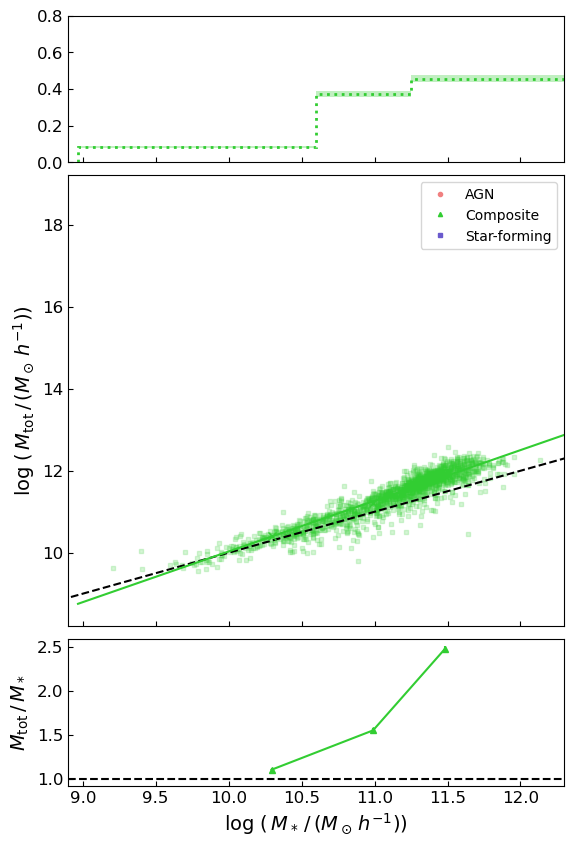

In [86]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))

ax[0].stairs([len(mid_z_mtot[0])/2 / len(mid_z),
              len(mid_z_mtot[1])/len(mid_z),
              len(mid_z_mtot[2])/len(mid_z)], mid_z_bins,
             color='limegreen', alpha=1, label=r'mid Z', linestyle=':',lw=2)

ax[0].stairs([(len(mid_z_mtot[0])/2 +np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])+np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])+np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             mid_z_bins,
                baseline=[(len(mid_z_mtot[0])/2 -np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])-np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])-np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             color='limegreen', alpha=0.3, lw=2, fill=True)


ax[1].scatter(mid_z['sphd_M_star_h'], mid_z['Mvir'], color='limegreen', marker='s', alpha=0.2, s=8)
ax[1].errorbar(mid_z_ctr, mid_z_mtot_avg, yerr=mid_z_mtot_sig, marker='x', color='limegreen', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)



ax[2].errorbar(mid_z_ctr, mid_z_mtot_mstar_avg, color='limegreen', yerr=mid_z_mtot_mstar_sig, 
             marker='^', markersize=5, )

ax[1].plot(bins,  mid_z_mtot_popt[0]*bins + mid_z_mtot_popt[1], color='limegreen')


ax[2].axhline(1 , color='k', linestyle='--')

# ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
# plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

#### high z

In [87]:
high_z_mtot_mstar = []
high_z_mtot = []
high_z_ctr = []

high_z_bins = bins
high_z_bins = np.concatenate((bins[:1], bins[2:]))

indices = np.digitize(high_z['sphd_M_star_h'], high_z_bins)

for i in range(1, len(high_z_bins)):

    high_z_mtot.append(high_z['Mvir'][indices==i])
    high_z_mtot_mstar.append(high_z_ellipticals_mtot_mstar[indices==i])
    high_z_ctr.append(np.mean(high_z['sphd_M_star_h'][indices==i]))
    

high_z_mtot_mstar_avg, high_z_mtot_mstar_sig = fit_to_gaussian(high_z_mtot_mstar, plot_dir = plot_dir, 
                                                         plot_name='high_z_Mtot_Mstar', xlab=r'$M_{\rm tot}/M_*$',
                                                              use_custom_bins=True,
                                                              custom_bins=[np.linspace(0,2,5),
                                                                           9,
                                                                           13
                                                              ]
                                                              )


high_z_mtot_avg, high_z_mtot_sig = fit_to_gaussian(high_z_mtot, plot_dir = plot_dir, 
                                                         plot_name='high_z_Mtot', xlab=r'$M_{\rm tot}$')

high_z_mtot_popt, hgih_z_mtot_pcov = curve_fit(lin_fit, high_z_ctr, 
                                       high_z_mtot_avg, sigma=high_z_mtot_sig)

print(high_z_mtot_popt, np.sqrt(hgih_z_mtot_pcov[0,0]), np.sqrt(hgih_z_mtot_pcov[1,1]))

[ 1.09589603 -0.8249992 ] 0.028183266005579473 0.3159215123621785


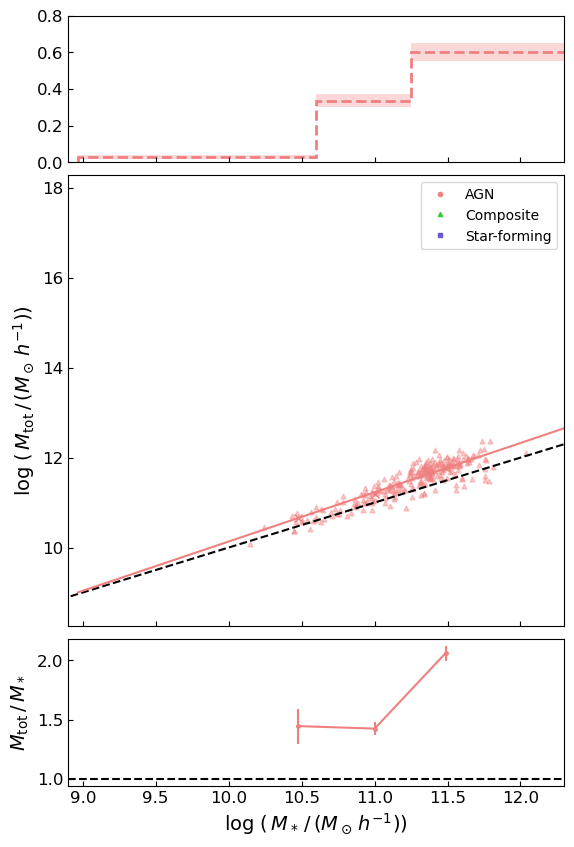

In [88]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))

ax[0].stairs([len(high_z_mtot[0])/2 /len(high_z),
              len(high_z_mtot[1])/len(high_z),
              len(high_z_mtot[2])/len(high_z)], 
             high_z_bins,
             color='lightcoral', alpha=1, label=r'high Z', linestyle='--', lw=2)


ax[0].stairs([(len(high_z_mtot[0])/2 + np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) + np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) + np.sqrt(len(high_z_mtot[2])))/len(high_z)], 
             high_z_bins,
                baseline=[(len(high_z_mtot[0])/2 - np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) - np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) - np.sqrt(len(high_z_mtot[2])))/len(high_z)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)


ax[1].scatter(high_z['sphd_M_star_h'], high_z['Mvir'], color='lightcoral', marker='^', alpha=0.4, s=12)


ax[1].errorbar(high_z_ctr, high_z_mtot_avg, yerr=high_z_mtot_sig, marker='x', color='lightcoral', linestyle='none')

ax[1].set_xlim(8.9,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)



ax[2].errorbar(high_z_ctr, high_z_mtot_mstar_avg, color='lightcoral', yerr=high_z_mtot_mstar_sig, 
             marker='.', markersize=5, )
ax[1].plot(bins,  high_z_mtot_popt[0]*bins + high_z_mtot_popt[1], color='lightcoral')


ax[2].axhline(1 , color='k', linestyle='--')

# ax[2].set_ylim(0,2.8)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
# plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

#### combine

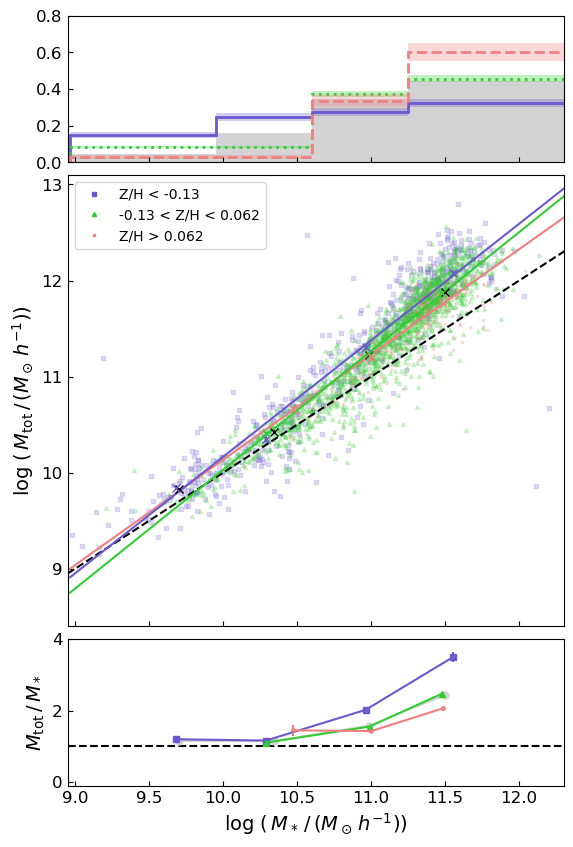

In [91]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(1.3,4, 1.3), figsize=(6.4,10))
ax[0].stairs([len(all_mtot[0])/len(ellipticals),len(all_mtot[1])/len(ellipticals),
              len(all_mtot[2])/len(ellipticals), len(all_mtot[3])/len(ellipticals)], all_bins, 
             color='lightgrey', fill=True, alpha=1, label=r'all ellipticals')

         
ax[0].stairs([len(low_z_mtot[0])/len(low_z),len(low_z_mtot[1])/len(low_z),
              len(low_z_mtot[2])/len(low_z), len(low_z_mtot[3])/len(low_z)], 
             low_z_bins,
             color='slateblue', alpha=1, label=r'low Z', lw=2)

ax[0].stairs([(len(low_z_mtot[0])+np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])+np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])+np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])+np.sqrt(len(low_z_mtot[3])))/len(low_z)], 
             low_z_bins,
                baseline=[(len(low_z_mtot[0])-np.sqrt(len(low_z_mtot[0])))/len(low_z),
              (len(low_z_mtot[1])-np.sqrt(len(low_z_mtot[1])))/len(low_z),
              (len(low_z_mtot[2])-np.sqrt(len(low_z_mtot[2])))/len(low_z), 
              (len(low_z_mtot[3])-np.sqrt(len(low_z_mtot[3])))/len(low_z)],
             color='slateblue', alpha=0.3, label=r'sf', lw=2, fill=True)

ax[0].stairs([len(mid_z_mtot[0])/2 / len(mid_z),
              len(mid_z_mtot[1])/len(mid_z),
              len(mid_z_mtot[2])/len(mid_z)], mid_z_bins,
             color='limegreen', alpha=1, label=r'mid Z', linestyle=':',lw=2)

ax[0].stairs([(len(mid_z_mtot[0])/2 +np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])+np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])+np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             mid_z_bins,
                baseline=[(len(mid_z_mtot[0])/2 -np.sqrt(len(mid_z_mtot[0])/2))/ len(mid_z),
              (len(mid_z_mtot[1])-np.sqrt(len(mid_z_mtot[1])))/len(mid_z),
              (len(mid_z_mtot[2])-np.sqrt(len(mid_z_mtot[2])))/len(mid_z)],
             color='limegreen', alpha=0.3, lw=2, fill=True)



ax[0].stairs([len(high_z_mtot[0])/2 /len(high_z),
              len(high_z_mtot[1])/len(high_z),
              len(high_z_mtot[2])/len(high_z)], 
             high_z_bins,
             color='lightcoral', alpha=1, label=r'high Z', linestyle='--', lw=2)


ax[0].stairs([(len(high_z_mtot[0])/2 + np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) + np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) + np.sqrt(len(high_z_mtot[2])))/len(high_z)], 
             high_z_bins,
                baseline=[(len(high_z_mtot[0])/2 - np.sqrt(len(high_z_mtot[0])/2))/len(high_z),
              (len(high_z_mtot[1]) - np.sqrt(len(high_z_mtot[1])))/len(high_z),
              (len(high_z_mtot[2]) - np.sqrt(len(high_z_mtot[2])))/len(high_z)],
             color='lightcoral', alpha=0.3, label=r'sf', lw=2, fill=True)




# ax[1].scatter(ellipticals['sphd_M_star_h'], ellipticals['Mvir'], color='lightgrey',edgecolor='none', alpha=1)
ax[1].scatter(low_z['sphd_M_star_h'], low_z['Mvir'], color='slateblue', marker='s', alpha=0.2, s=8)
ax[1].scatter(mid_z['sphd_M_star_h'], mid_z['Mvir'], color='limegreen', marker='^', alpha=0.2, s=8)
ax[1].scatter(high_z['sphd_M_star_h'], high_z['Mvir'], color='lightcoral', marker='.', alpha=0.2, s=12)


ax[1].errorbar(all_ctr, all_mtot_avg, yerr=all_mtot_sig, marker='x', color='k', linestyle='none')
ax[1].errorbar(low_z_ctr, low_z_mtot_avg, yerr=low_z_mtot_sig, marker='x', color='slateblue', linestyle='none')
ax[1].errorbar(mid_z_ctr, mid_z_mtot_avg, yerr=mid_z_mtot_sig, marker='x', color='limegreen', linestyle='none')
ax[1].errorbar(high_z_ctr, high_z_mtot_avg, yerr=high_z_mtot_sig, marker='x', color='lightcoral', linestyle='none')

ax[1].set_xlim(8.95,12.3)
ax[2].set_xlabel(r'$\log\,(\,M_*\,/\,(M_\odot\,h^{-1}))$', fontsize=14)
ax[1].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=14)

legend_elements = [Line2D([0], [0], marker='s', color='w', label=f'Z/H < {z_bins[1]:.2}',
                          markeredgecolor='slateblue', mfc='slateblue',markersize=3),
                   Line2D([0], [0], marker='^', color='w', label=f'{z_bins[1]:.2} < Z/H < {z_bins[2]:.2}',
                          markeredgecolor='limegreen', mfc='limegreen',markersize=3),
                   Line2D([0], [0], marker='.', color='w', label=f'Z/H > {z_bins[2]:.2}',
                          markeredgecolor='lightcoral', mfc='lightcoral', markersize=3)]

ax[1].tick_params( axis='both', direction='in', labelsize=12)
ax[0].tick_params( axis='both', direction='in', labelsize=12)
ax[2].tick_params( axis='both', direction='in', labelsize=12)
ax[1].plot([8.7,13],[8.7,13], color='k', linestyle='--')
ax[0].set_ylim(0,0.8)



ax[2].errorbar(all_ctr, all_mtot_mstar_avg, color='lightgrey', yerr=np.abs(all_mtot_mstar_sig), 
             marker='o', markersize=5, )

ax[2].errorbar(low_z_ctr, low_z_mtot_mstar_avg, color='slateblue', yerr=np.abs(low_z_mtot_mstar_sig), 
             marker='s', markersize=5, )
ax[2].errorbar(mid_z_ctr, mid_z_mtot_mstar_avg, color='limegreen', yerr=np.abs(mid_z_mtot_mstar_sig), 
             marker='^', markersize=5, )
ax[2].errorbar(high_z_ctr, high_z_mtot_mstar_avg, color='lightcoral', yerr=np.abs(high_z_mtot_mstar_sig), 
             marker='.', markersize=5, )

ax[1].plot(bins,  high_z_mtot_popt[0]*bins + high_z_mtot_popt[1], color='lightcoral')
ax[1].plot(bins,  mid_z_mtot_popt[0]*bins + mid_z_mtot_popt[1], color='limegreen')
ax[1].plot(bins,  low_z_mtot_popt[0]*bins + low_z_mtot_popt[1], color='slateblue')



ax[2].axhline(1 , color='k', linestyle='--')

ax[1].set_ylim(8.4,13.1)
ax[2].set_ylim(-0.1,4)
ax[2].set_ylabel(r'$M_{\rm tot}\, /\, M_*$', fontsize=14)


fig.subplots_adjust(hspace=0.05)
ax[1].legend(handles=legend_elements)
plt.savefig(plot_dir + 'paper_plots/Mtot_Mstar_ZH_hist.png', bbox_inches='tight')

## BTFR plots

In [30]:
# def vel_from_mass(M,r):
#     '''
#     take log mass, r (kpc), return vel
    
#     '''
#     v = np.sqrt(10**M * G / r)
    
#     return v

### in terms of "velocities"

In [31]:
# ellipticals['v_eff'] = vel_from_mass(ellipticals['Mvir'], ellipticals['R90_kpc'])
# HI_spirals['v_eff'] = vel_from_mass(HI_spirals['M_R90'], HI_spirals['R90_kpc'])

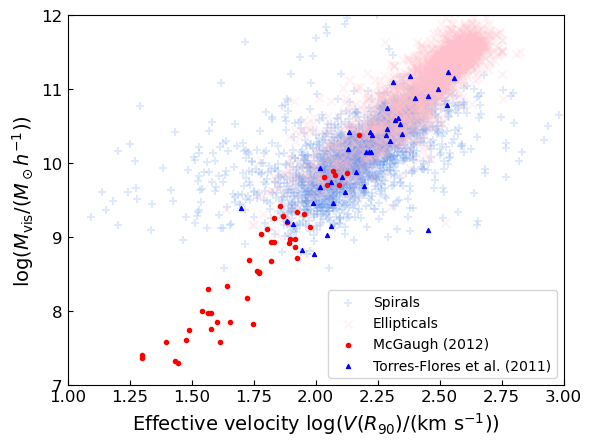

In [67]:
plt.scatter(np.log10(HI_spirals['V_R90']), HI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Spirals')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='r', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='b', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
# plt.savefig(plot_dir + 'BTFR_desmond_compare.png', bbox_inches='tight')

In [68]:
v_eff_bins = np.linspace(np.min([np.log10(np.min(ellipticals['v_eff'])), np.log10(np.min(HI_spirals['V_R90']))]),
                         np.max([np.log10(np.max(ellipticals['v_eff'])), np.log10(np.max(HI_spirals['V_R90']))]),
                         15)

### ellipticals

In [69]:
e_mvis = []
e_mvis_ctr = []
e_mvis_bins = v_eff_bins
e_mvis_bins = np.concatenate((v_eff_bins[:1], v_eff_bins[6:-3], v_eff_bins[-1:]))
indices = np.digitize(np.log10(ellipticals['v_eff']), e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_mvis.append(ellipticals['sphd_M_star_h'][indices==i])
    e_mvis_ctr.append(np.mean(np.log10(ellipticals['v_eff'][indices==i])))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_mvis, plot_dir = plot_dir + '/e_mvis_veff/', 
                                                         plot_name='e_mvis_veff', xlab=r'$M_{\rm vis}$')

e_mvis_veff_popt, e_mvis_veff_pcov = curve_fit(lin_fit, e_mvis_ctr, 
                                       e_mvis_veff_avg, sigma=e_mvis_veff_sig)

In [70]:
print(e_mvis_veff_popt[0], ' +- ', np.sqrt(e_mvis_veff_pcov[0,0]))
print(e_mvis_veff_popt[1], ' +- ', np.sqrt(e_mvis_veff_pcov[1][1]))

2.641975682080704  +-  0.1588945581420013
4.609937345270242  +-  0.3989263446275597


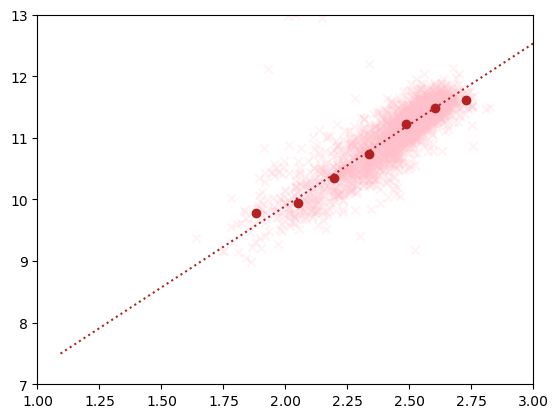

In [71]:
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)
plt.ylim(7,13)
plt.xlim(1,3)
plt.errorbar(e_mvis_ctr, e_mvis_veff_avg, yerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins*e_mvis_veff_popt[0] + e_mvis_veff_popt[1], linestyle=':', color='firebrick')

### spirals

In [72]:
s_mvis_bins

array([ 8.56248949,  9.40624174,  9.68749249,  9.96874325, 10.249994  ,
       10.53124475, 10.8124955 , 12.5       ])

In [74]:
s_mvis = []
s_mvis_ctr = []
s_mvis_bins = v_eff_bins
s_mvis_bins = np.concatenate((v_eff_bins[:1], v_eff_bins[6:-5], v_eff_bins[-1:]))
indices = np.digitize(np.log10(HI_spirals['V_R90']), s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_mvis.append(HI_spirals['Mstar_MHI_h'][indices==i])
    s_mvis_ctr.append(np.mean(np.log10(HI_spirals['v_eff'][indices==i])))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_mvis, plot_dir = plot_dir, 
                                                         plot_name='s_mvis_veff', xlab=r'$M_{\rm vis}$')

s_mvis_veff_popt, s_mvis_veff_pcov = curve_fit(lin_fit, s_mvis_ctr, 
                                       s_mvis_veff_avg, sigma=s_mvis_veff_sig)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_7428/106845178.py:10: RuntimeWarning: invalid value encountered in log10
  s_mvis_ctr.append(np.mean(np.log10(HI_spirals['v_eff'][indices==i])))


ValueError: array must not contain infs or NaNs

In [39]:
print(s_mvis_veff_popt[0], ' +- ', np.sqrt(s_mvis_veff_pcov[0,0]))
print(s_mvis_veff_popt[1], ' +- ', np.sqrt(s_mvis_veff_pcov[1][1]))

1.8677038895027702  +-  0.3320656141857331
6.082017298684832  +-  0.7282495284235951


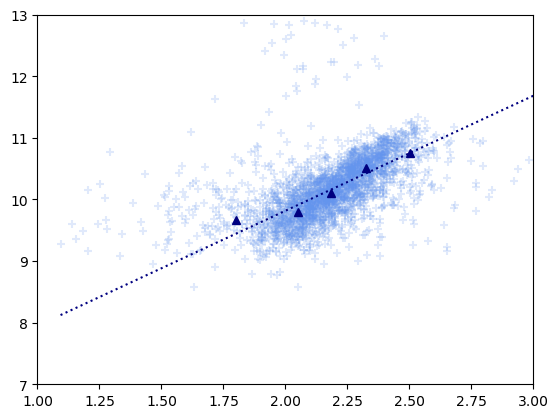

In [40]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', color='cornflowerblue', alpha=0.2)
plt.ylim(7,13)
plt.xlim(1,3)
plt.errorbar(s_mvis_ctr, s_mvis_veff_avg, yerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins*s_mvis_veff_popt[0] + s_mvis_veff_popt[1], linestyle=':', color='navy')

### combine

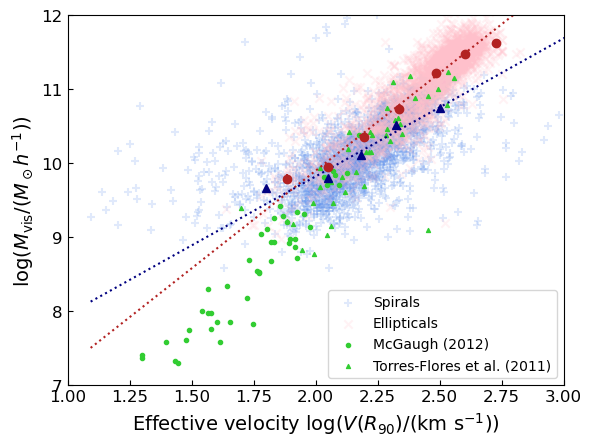

In [41]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', color='cornflowerblue', alpha=0.2, label='Spirals')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')

plt.errorbar(s_mvis_ctr, s_mvis_veff_avg, yerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins*s_mvis_veff_popt[0] + s_mvis_veff_popt[1], linestyle=':', color='navy')
plt.errorbar(e_mvis_ctr, e_mvis_veff_avg, yerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins*e_mvis_veff_popt[0] + e_mvis_veff_popt[1], linestyle=':', color='firebrick')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
plt.savefig(plot_dir + 'BTFR_desmond_compare.png', bbox_inches='tight')

### now bin the other way :/

In [76]:
mvis_bins = np.linspace(np.min([np.min(HI_spirals['Mstar_MHI_h']), np.min(ellipticals['sphd_M_star_h'])])-0.01,
                  12.5, 15)

In [77]:
e_veff = []
e_veff_ctr = []
e_mvis_bins = mvis_bins
e_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[4:-3], mvis_bins[-1:]))
indices = np.digitize(ellipticals['sphd_M_star_h'], e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_veff.append(np.log10(ellipticals['v_eff'])[indices==i])
    e_veff_ctr.append(np.mean(ellipticals['sphd_M_star_h'][indices==i]))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_veff, plot_dir = plot_dir +'/e_mvis_veff/', 
                                                         plot_name='e_v_eff_mvis', xlab=r'$M_{\rm vis}$')

e_mvis_veff_popt, e_mvis_veff_pcov = curve_fit(lin_fit, e_veff_ctr, 
                                       e_mvis_veff_avg, sigma=e_mvis_veff_sig)

print(e_mvis_veff_popt[0], ' +- ', np.sqrt(e_mvis_veff_pcov[0,0]))
print(e_mvis_veff_popt[1], ' +- ', np.sqrt(e_mvis_veff_pcov[1][1]))

0.2865566987504719  +-  0.012568634018612345
-0.7148682477549698  +-  0.14092429481017787


In [78]:
print(1/e_mvis_veff_popt[0])
print(1/e_mvis_veff_popt[0]**2 * e_mvis_veff_pcov[0,0])

3.489710777519743
0.0019237783377033513


In [79]:
print(-e_mvis_veff_popt[1]/e_mvis_veff_popt[0])
err = np.sqrt(e_mvis_veff_pcov[1,1]**2/e_mvis_veff_popt[0]**2 +(e_mvis_veff_popt[1]/e_mvis_veff_popt[0]**2)**2 * e_mvis_veff_pcov[0,0]**2)
print(err)

2.4946834286971717
0.06931810218344041


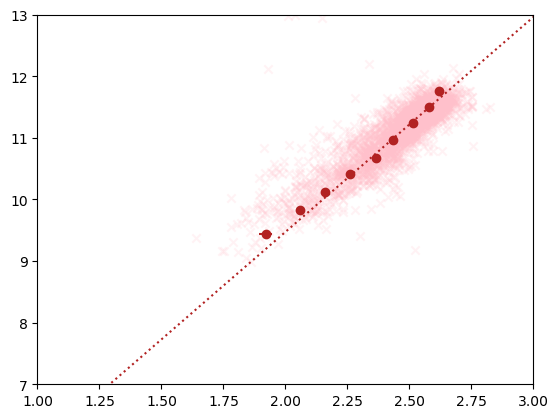

In [80]:
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)
plt.ylim(7,13)
plt.xlim(1,3)
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')

In [83]:
s_mvis_veff_avg

array([ 9.64922177,  9.79711152, 10.11237614, 10.5078411 , 10.74941568])

In [85]:
s_veff = []
s_veff_ctr = []
s_mvis_bins = mvis_bins
s_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
indices = np.digitize(HI_spirals['Mstar_MHI_h'], s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_veff.append(np.log10(HI_spirals['V_R90'])[indices==i])
    s_veff_ctr.append(np.mean(HI_spirals['Mstar_MHI_h'][indices==i]))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_veff, plot_dir = plot_dir + '/s_mvis_veff/', 
                                                         plot_name='s_v_eff_mvis', xlab=r'$M_{\rm vis}$')

s_mvis_veff_popt, s_mvis_veff_pcov = curve_fit(lin_fit, s_veff_ctr, 
                                       s_mvis_veff_avg, sigma=s_mvis_veff_sig)

print(s_mvis_veff_popt[0], ' +- ', np.sqrt(s_mvis_veff_pcov[0,0]))
print(s_mvis_veff_popt[1], ' +- ', np.sqrt(s_mvis_veff_pcov[1][1]))

0.2665299125639311  +-  0.011044766634750383
-0.50824484808883  +-  0.11302610704063554


In [86]:
print(1/s_mvis_veff_popt[0])
print(1/s_mvis_veff_popt[0]**2 * s_mvis_veff_pcov[0,0])

3.75192409129739
0.001717201165274718


In [87]:
print(-s_mvis_veff_popt[1]/s_mvis_veff_popt[0])
err = np.sqrt(s_mvis_veff_pcov[1,1]**2/s_mvis_veff_popt[0]**2 +(s_mvis_veff_popt[1]/s_mvis_veff_popt[0]**2)**2 * s_mvis_veff_pcov[0,0]**2)
print(err)

1.9068960898222633
0.04793840365662458


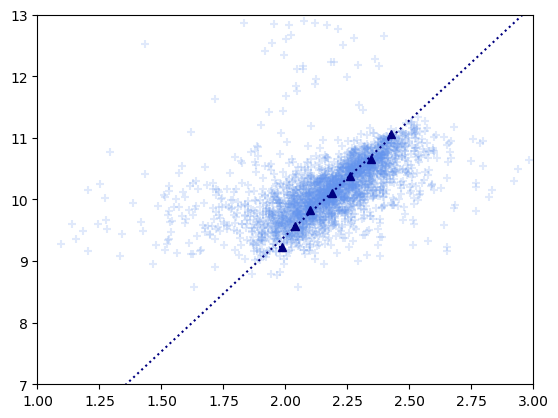

In [89]:
plt.scatter(np.log10(HI_spirals['V_R90']), HI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2)
plt.ylim(7,13)
plt.xlim(1,3)
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins/s_mvis_veff_popt[0] - s_mvis_veff_popt[1]/s_mvis_veff_popt[0], linestyle=':', color='navy')

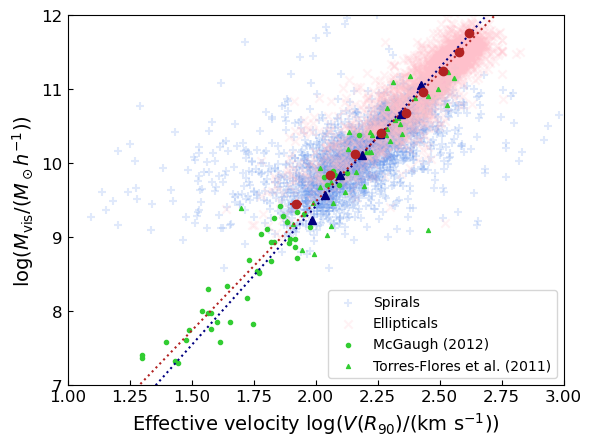

In [90]:

plt.scatter(np.log10(HI_spirals['V_R90']), HI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Spirals')
plt.errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins/s_mvis_veff_popt[0] - s_mvis_veff_popt[1]/s_mvis_veff_popt[0], linestyle=':', color='navy')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
plt.savefig(plot_dir + 'paper_plots/BTFR_desmond_compare_mvis_bin.png', bbox_inches='tight')

 ### blue spirals only

In [92]:
bs_veff = []
bs_veff_ctr = []
# bs_mvis_bins = mvis_bins
bs_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[3:-6], mvis_bins[-1:]))
bHI_spirals = HI_spirals[HI_spirals['CMD_class']==1]

indices = np.digitize(bHI_spirals['Mstar_MHI_h'], bs_mvis_bins)

for i in range(1, len(bs_mvis_bins)):

    bs_veff.append(np.log10(bHI_spirals['V_R90'])[indices==i])
    bs_veff_ctr.append(np.mean(bHI_spirals['Mstar_MHI_h'][indices==i]))

bs_mvis_veff_avg, bs_mvis_veff_sig = fit_to_gaussian(bs_veff, plot_dir = plot_dir + '/bs_mvis_veff/', 
                                                         plot_name='bs_v_eff_mvis', xlab=r'$M_{\rm vis}$')

bs_mvis_veff_popt, bs_mvis_veff_pcov = curve_fit(lin_fit, bs_veff_ctr, 
                                       bs_mvis_veff_avg, sigma=bs_mvis_veff_sig)

print(bs_mvis_veff_popt[0], ' +- ', np.sqrt(bs_mvis_veff_pcov[0,0]))
print(bs_mvis_veff_popt[1], ' +- ', np.sqrt(bs_mvis_veff_pcov[1][1]))

0.24388501858716335  +-  0.0177220916741659
-0.2894575887289902  +-  0.18003306922880385


In [93]:
print(1/bs_mvis_veff_popt[0])
print(1/bs_mvis_veff_popt[0]**2 * bs_mvis_veff_pcov[0,0])

4.1002928584668465
0.005280313538001303


In [94]:
print(-bs_mvis_veff_popt[1]/bs_mvis_veff_popt[0])
err = np.sqrt(bs_mvis_veff_pcov[1,1]**2/bs_mvis_veff_popt[0]**2 +(bs_mvis_veff_popt[1]/bs_mvis_veff_popt[0]**2)**2 * bs_mvis_veff_pcov[0,0]**2)
print(err)

1.186860883894512
0.13290709548384794


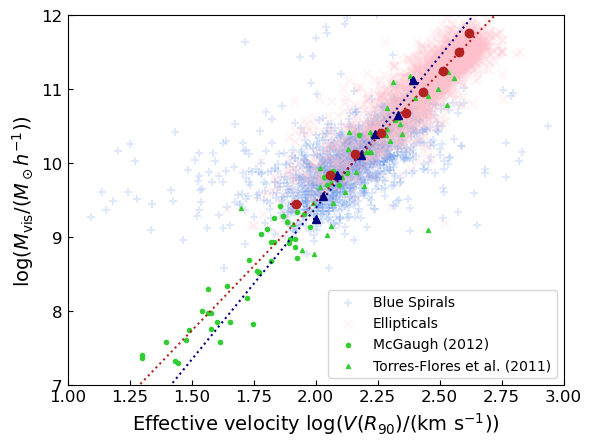

In [95]:

plt.scatter(np.log10(bHI_spirals['V_R90']), bHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Blue Spirals')
plt.errorbar(bs_mvis_veff_avg, bs_veff_ctr, xerr=bs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins/bs_mvis_veff_popt[0] - bs_mvis_veff_popt[1]/bs_mvis_veff_popt[0], linestyle=':', color='navy')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
# plt.savefig(plot_dir + 'paper_plots/BTFR_desmond_compare_mvis_bin.png', bbox_inches='tight')

### green spirals

In [96]:
gs_veff = []
gs_veff_ctr = []
gs_mvis_bins = mvis_bins
gs_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[4:9], mvis_bins[-1:]))
gHI_spirals = HI_spirals[HI_spirals['CMD_class']==2]

indices = np.digitize(gHI_spirals['Mstar_MHI_h'], gs_mvis_bins)

for i in range(1, len(gs_mvis_bins)):

    gs_veff.append(np.log10(gHI_spirals['V_R90'])[indices==i])
    gs_veff_ctr.append(np.mean(gHI_spirals['Mstar_MHI_h'][indices==i]))

gs_mvis_veff_avg, gs_mvis_veff_sig = fit_to_gaussian(gs_veff, plot_dir = plot_dir + '/gs_mvis_veff/', 
                                                         plot_name='gs_v_eff_mvis', xlab=r'$M_{\rm vis}$')

gs_mvis_veff_popt, gs_mvis_veff_pcov = curve_fit(lin_fit, gs_veff_ctr, 
                                       gs_mvis_veff_avg, sigma=gs_mvis_veff_sig)

print(gs_mvis_veff_popt[0], ' +- ', np.sqrt(gs_mvis_veff_pcov[0,0]))
print(gs_mvis_veff_popt[1], ' +- ', np.sqrt(gs_mvis_veff_pcov[1][1]))

0.2661319155839719  +-  0.006272585334107764
-0.48743272547298916  +-  0.06587168653521172


In [97]:
print(1/gs_mvis_veff_popt[0])
print(1/gs_mvis_veff_popt[0]**2 * gs_mvis_veff_pcov[0,0])

3.757535047255437
0.0005555194083856937


In [98]:
print(-gs_mvis_veff_popt[1]/gs_mvis_veff_popt[0])
err = np.sqrt(gs_mvis_veff_pcov[1,1]**2/gs_mvis_veff_popt[0]**2 +(gs_mvis_veff_popt[1]/gs_mvis_veff_popt[0]**2)**2 * gs_mvis_veff_pcov[0,0]**2)
print(err)

1.831545549143995
0.016306490109670967


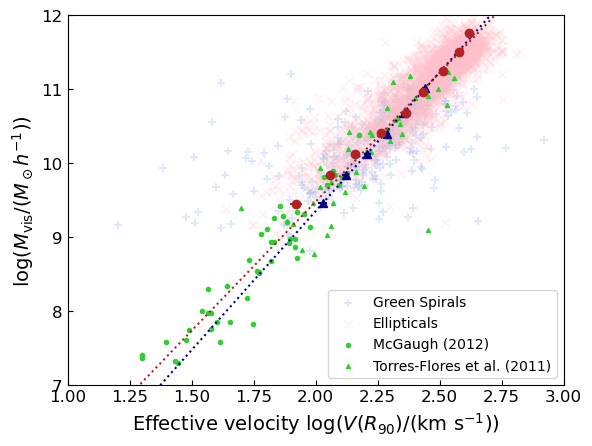

In [99]:
plt.scatter(np.log10(gHI_spirals['V_R90']), gHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Green Spirals')
plt.errorbar(gs_mvis_veff_avg, gs_veff_ctr, xerr=gs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins/gs_mvis_veff_popt[0] - gs_mvis_veff_popt[1]/gs_mvis_veff_popt[0], linestyle=':', color='navy')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
# plt.savefig(plot_dir + 'paper_plots/BTFR_desmond_compare_mvis_bin.png', bbox_inches='tight')

### red spiral

In [100]:
rs_veff = []
rs_veff_ctr = []
rs_mvis_bins = mvis_bins
rs_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[6:8], mvis_bins[-1:]))
rHI_spirals = HI_spirals[HI_spirals['CMD_class']==3]

indices = np.digitize(rHI_spirals['Mstar_MHI_h'], rs_mvis_bins)

for i in range(1, len(rs_mvis_bins)):

    rs_veff.append(np.log10(rHI_spirals['V_R90'])[indices==i])
    rs_veff_ctr.append(np.mean(rHI_spirals['Mstar_MHI_h'][indices==i]))

rs_mvis_veff_avg, rs_mvis_veff_sig = fit_to_gaussian(rs_veff, plot_dir = plot_dir + '/rs_mvis_veff/', 
                                                         plot_name='rs_v_eff_mvis', xlab=r'$M_{\rm vis}$')

rs_mvis_veff_popt, rs_mvis_veff_pcov = curve_fit(lin_fit, rs_veff_ctr, 
                                       rs_mvis_veff_avg, sigma=rs_mvis_veff_sig)

print(rs_mvis_veff_popt[0], ' +- ', np.sqrt(rs_mvis_veff_pcov[0,0]))
print(rs_mvis_veff_popt[1], ' +- ', np.sqrt(rs_mvis_veff_pcov[1][1]))

0.1708309881281713  +-  0.053855153114787266
0.5510405894125484  +-  0.5659692515765705


In [101]:
print(1/rs_mvis_veff_popt[0])
print(1/rs_mvis_veff_popt[0]**2 * rs_mvis_veff_pcov[0,0])

5.853738896889824
0.09938508740750174


In [102]:
print(-rs_mvis_veff_popt[1]/rs_mvis_veff_popt[0])
err = np.sqrt(rs_mvis_veff_pcov[1,1]**2/rs_mvis_veff_popt[0]**2 +(rs_mvis_veff_popt[1]/rs_mvis_veff_popt[0]**2)**2 * rs_mvis_veff_pcov[0,0]**2)
print(err)

-3.2256477320093295
1.8758762224670804


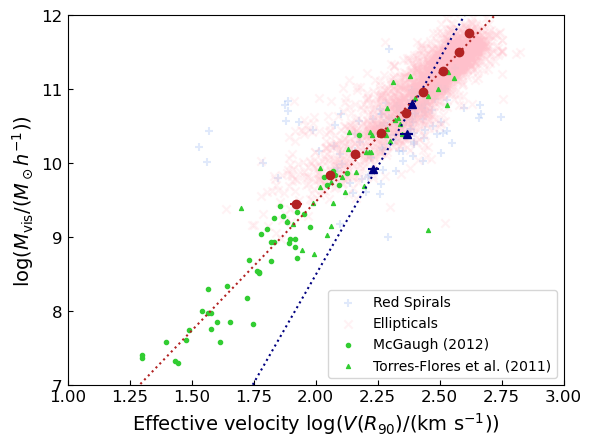

In [104]:
plt.scatter(np.log10(rHI_spirals['V_R90']), rHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Red Spirals')
plt.errorbar(rs_mvis_veff_avg, rs_veff_ctr, xerr=rs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
plt.plot(v_eff_bins, v_eff_bins/rs_mvis_veff_popt[0] - rs_mvis_veff_popt[1]/rs_mvis_veff_popt[0], linestyle=':', color='navy')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
plt.plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')

plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='limegreen', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
# plt.savefig(plot_dir + 'paper_plots/BTFR_desmond_compare_mvis_bin.png', bbox_inches='tight')

### combined figure

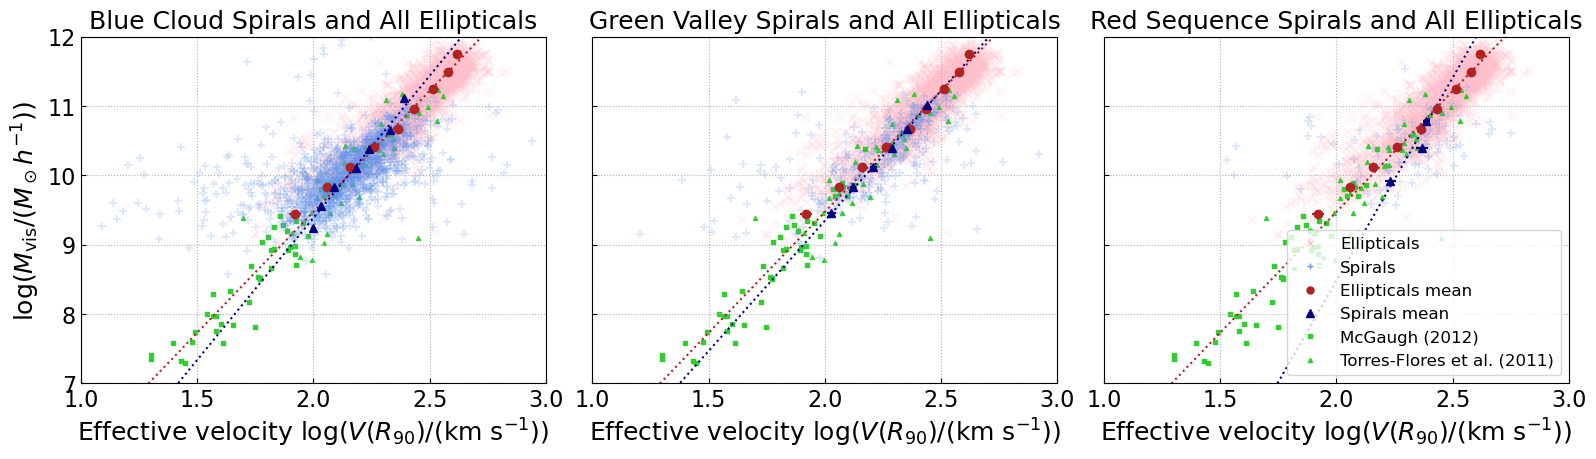

In [105]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(19.2,4.5))

for i in range(3):
    ax[i].scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
    ax[i].errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
            marker='o', color='firebrick')
    ax[i].plot(v_eff_bins, v_eff_bins/e_mvis_veff_popt[0] - e_mvis_veff_popt[1]/e_mvis_veff_popt[0], linestyle=':', color='firebrick')
    ax[i].set_xlim(1,3)
    ax[i].set_xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=18)
    ax[i].scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='s', color='limegreen', label='McGaugh (2012)', s=8)
    ax[i].scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='limegreen', s=8, label='Torres-Flores et al. (2011)')

    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid( linestyle=':')



ax[0].scatter(np.log10(bHI_spirals['V_R90']), bHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Blue Spirals')
ax[0].errorbar(bs_mvis_veff_avg, bs_veff_ctr, xerr=bs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
ax[0].plot(v_eff_bins, v_eff_bins/bs_mvis_veff_popt[0] - bs_mvis_veff_popt[1]/bs_mvis_veff_popt[0], linestyle=':', color='navy')
ax[1].scatter(np.log10(gHI_spirals['V_R90']), gHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Green Spirals')
ax[1].errorbar(gs_mvis_veff_avg, gs_veff_ctr, xerr=gs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
ax[1].plot(v_eff_bins, v_eff_bins/gs_mvis_veff_popt[0] - gs_mvis_veff_popt[1]/gs_mvis_veff_popt[0], linestyle=':', color='navy')

ax[2].scatter(np.log10(rHI_spirals['V_R90']), rHI_spirals['Mstar_MHI_h'], marker='+', color='cornflowerblue', alpha=0.2, label='Red Spirals')
ax[2].errorbar(rs_mvis_veff_avg, rs_veff_ctr, xerr=rs_mvis_veff_sig, linestyle='none',
            marker='^', color='navy')
ax[2].plot(v_eff_bins, v_eff_bins/rs_mvis_veff_popt[0] - rs_mvis_veff_popt[1]/rs_mvis_veff_popt[0], linestyle=':', color='navy')


ax[0].set_ylim(7,12)
ax[0].set_ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=18)


ax[0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)

legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=3),
                  Line2D([0], [0], marker='^', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=3)]


ax[2].legend(handles=legend_elements,fontsize=12, loc='lower right')

fig.subplots_adjust(wspace=0.1, hspace=0.05)
plt.savefig(plot_dir + 'paper_plots/BTFR_desmond_compare_CMD_mvis_bin.png', bbox_inches='tight')

### fitting BTFR slope with full sample

In [355]:
def chi2(theta, v, verr, m, merr, e_mask):
    a, b, fx, fy = theta
    sy2 = merr**2 + fy**2 * (a + b*v)**2

    # if morph=='e':
    #     sx2 = fx**2 * verr**2

    # else:
    #     sx2 = verr**2
    
    x_e = np.sum((m[e_mask] - (a + b*v[e_mask]))**2/(sy2[e_mask] + b**2 * fx**2 * verr[e_mask]**2))
    x_s = np.sum((m[~e_mask] - (a + b*v[~e_mask]))**2/(sy2[~e_mask] + b**2 * verr[~e_mask]**2))


    return ma.sum([x_s, x_e])

def chi2_yint(theta, v, verr, m, merr, e_mask):
    a, fx, fy = theta
    sy2 = merr**2 + fy**2 * (a + 4*v)**2

    x_e = np.sum((m[e_mask] - (a + 4*v[e_mask]))**2/(sy2[e_mask] + 4**2 * fx**2 * verr[e_mask]**2))
    x_s = np.sum((m[~e_mask] - (a + 4*v[~e_mask]))**2/(sy2[~e_mask] + 4**2 * verr[~e_mask]**2))

    
    return x_e+x_s

def chi2_no_err(theta, v, verr, m, merr):
    a, b = theta
    # sy2 = merr**2 + fy**2 * (a + b*v)**2

    # if morph=='e':
    #     sx2 = fx**2 * verr**2

    # else:
    #     sx2 = verr**2
    
    x = np.sum((m - (a + b*v))**2/(merr**2 + b**2 * verr**2)**2)


    return x

In [356]:
vs = np.concatenate((HI_spirals['V_R90'], ellipticals['v_eff']))
v_errs = np.concatenate((HI_spirals['V_R90_err'], ellipticals['v_eff_err']))
ms = np.concatenate((HI_spirals['Mstar_MHI_h'], ellipticals['sphd_M_star_h']))
m_errs = np.concatenate((HI_spirals['sphd_M_star_err_h'], ellipticals['sphd_M_star_err_h']))
e_mask = np.concatenate((HI_spirals['elliptical_mask'] ==1, ellipticals['elliptical_mask'] ==1))

In [361]:

p0 = [2,3.7]
bestfit = minimize(chi2_no_err,p0, method='Powell',
                   args = (np.log10(vs), np.log10(v_errs), ms, m_errs),
                   bounds = ((-100,100), (-100,100)))

# # p0 = [2, 3.7, 0, 0]


# p0 = [4, 10, 0, 0]

# # bestfit = minimize(chi2, p0, method='L-BFGS-B',
# #                    args=(np.log10(ellipticals['v_eff']), np.log10(ellipticals['v_eff_err']),
# #                          ellipticals['sphd_M_star_h'], ellipticals['sphd_M_star_h'], ellipticals['elliptical_mask'] == 1),
# #                    bounds=((-100,100.),
# #                            (-20.,20.),
# #                            (-50.,50.),
# #                           (-50,50)))
# bestfit = minimize(chi2, p0, method='L-BFGS-B',
#                    args=(np.log10(vs), np.log10(v_errs),
#                          ms, m_errs, e_mask),
#                    bounds=((-100,100.),
#                            (-20.,20.),
#                            (-10.,10.),
#                           (-10,10)))

# p0y = [2, 0, 0]

# bestfit_y = minimize(chi2_yint, p0y, method='L-BFGS-B',
#                    args=(np.log10(vs), np.log10(v_errs),
#                          ms, m_errs, e_mask),
#                    bounds=((-100,100.),
#                            (-10.,10.),
#                           (-10,10)))

In [362]:
bestfit

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.03474120158987927
       x: [ 6.450e+00  1.691e+00]
     nit: 17
   direc: [[ 3.130e-01 -1.803e-01]
           [-4.879e-01  1.989e-01]]
    nfev: 587

In [363]:
bestfit_y

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.19099967978070706
        x: [ 1.681e+00  1.000e+01  1.000e+01]
      nit: 18
      jac: [-2.637e-07 -5.074e-04 -3.698e-02]
     nfev: 160
     njev: 40
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(8.0, 13.0)

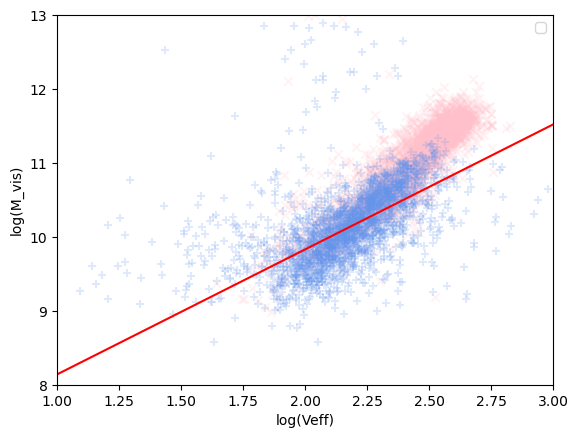

In [364]:
plt.scatter(np.log10(vs[e_mask]), ms[e_mask], alpha=0.2, marker='x', color='pink')
plt.scatter(np.log10(vs[~e_mask]), ms[~e_mask], alpha=0.2, marker='+', color='cornflowerblue')
plt.plot(np.linspace(1,3,100), bestfit.x[0] + bestfit.x[1] * np.linspace(1,3,100),  color='r')

# plt.plot(np.linspace(1,3,100), bestfit_y.x[0] + 4 * np.linspace(1,3,100),  color='green', label='fixed slope 4')
plt.legend()
plt.xlabel('log(Veff)')
plt.ylabel('log(M_vis)')

plt.xlim(1,3)
plt.ylim(8,13)

## SHMR

In [117]:
Mstars = np.linspace(7,13,1000)
Mhs_all = shmr_RP11(Mstars, 'all')
Mhs_blue = shmr_RP11(Mstars, 'blue')
Mhs_red = shmr_RP11(Mstars, 'red')

In [118]:
spirals['Mstar_tot'] = np.log10(0.73) + np.log10(8 * np.pi * spirals['R_bulge']**3 * spirals['rho_bulge'] + 2 * np.pi * spirals['Sigma_disk'] * spirals['R_disk']**2)
ellipticals['sphd_M_star_h'] = ellipticals['sphd_M_star'] + np.log10(0.73)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_75016/183959674.py:7: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(10**(spirals['M_R90'])-10**(spirals['Mstar_tot'])), spirals['Mstar_tot'], marker='+', color='cornflowerblue', alpha=0.2)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_75016/183959674.py:8: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(10**(ellipticals['Mvir'])-10**(ellipticals['sphd_M_star_h'])), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)


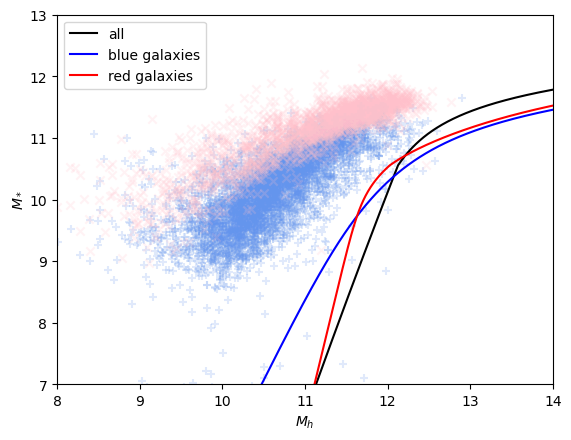

In [123]:
plt.plot(Mhs_all,Mstars, color='k', label='all')
plt.plot(Mhs_blue, Mstars,color='b', label='blue galaxies')
plt.plot( Mhs_red, Mstars,color='r', label='red galaxies')
plt.ylim(7,13)
plt.xlim(8, 14)

plt.scatter(np.log10(10**(spirals['M_R90'])-10**(spirals['Mstar_tot'])), spirals['Mstar_tot'], marker='+', color='cornflowerblue', alpha=0.2)
plt.scatter(np.log10(10**(ellipticals['Mvir'])-10**(ellipticals['sphd_M_star_h'])), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)

plt.xlabel(r'$M_h$')
plt.legend(loc = 'upper left')
plt.ylabel(r'$M_*$')
plt.savefig(plot_dir + 'paper_plots/SHMR_RP11.png')

## spirals inclination check

(array([ 50.,  40.,  16.,  25.,  24.,  15.,  18.,  19.,  20.,  21.,  21.,
         31.,  25.,  17.,  27.,  23.,  25.,  26.,  34.,  36.,  34.,  40.,
         37.,  50.,  61.,  66.,  50.,  70.,  62.,  95.,  66.,  65.,  88.,
         88.,  83.,  90., 100., 115., 113., 121., 101., 106., 114., 139.,
        130., 107., 135., 122., 115., 115.,  94.,  87., 110.,  83.,  93.,
         83.,  78.,  94.,  75.,  78.,  75.,  71.,  75.,  71.,  82.,  71.,
         77.,  95.,  84., 112., 114., 125., 137., 348.]),
 array([-2.07039251e-01, -2.01443387e-01, -1.95847523e-01, -1.90251658e-01,
        -1.84655794e-01, -1.79059930e-01, -1.73464066e-01, -1.67868202e-01,
        -1.62272337e-01, -1.56676473e-01, -1.51080609e-01, -1.45484745e-01,
        -1.39888881e-01, -1.34293016e-01, -1.28697152e-01, -1.23101288e-01,
        -1.17505424e-01, -1.11909560e-01, -1.06313696e-01, -1.00717831e-01,
        -9.51219671e-02, -8.95261029e-02, -8.39302387e-02, -7.83343745e-02,
        -7.27385104e-02, -6.71426462e-02, 

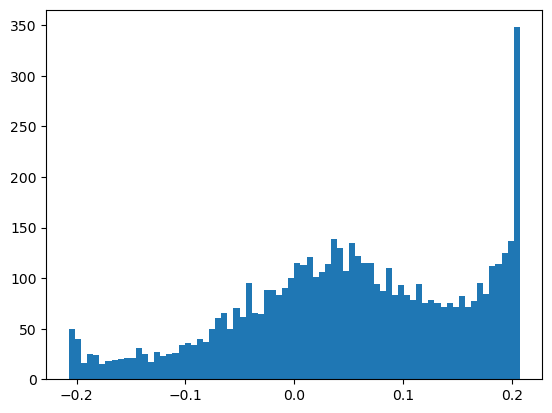

In [283]:
plt.hist(spirals['ba'] - spirals['nsa_elpetro_ba'], bins=int(np.sqrt(5500)))

(array([ 12.,  12.,  20.,  24.,  35.,  33.,  35.,  62.,  97.,  93.,  93.,
         97., 122., 143., 141., 175., 150., 187., 180., 170., 154., 186.,
        183., 175., 174., 204., 167., 195., 214., 189., 196., 174., 184.,
        190., 195., 183., 183., 241., 182., 153.]),
 array([0.20115764, 0.22112813, 0.24109862, 0.2610691 , 0.28103959,
        0.30101008, 0.32098057, 0.34095106, 0.36092155, 0.38089204,
        0.40086253, 0.42083302, 0.4408035 , 0.46077399, 0.48074448,
        0.50071497, 0.52068546, 0.54065595, 0.56062644, 0.58059693,
        0.60056741, 0.6205379 , 0.64050839, 0.66047888, 0.68044937,
        0.70041986, 0.72039035, 0.74036084, 0.76033133, 0.78030181,
        0.8002723 , 0.82024279, 0.84021328, 0.86018377, 0.88015426,
        0.90012475, 0.92009524, 0.94006572, 0.96003621, 0.9800067 ,
        0.99997719]),
 <BarContainer object of 40 artists>)

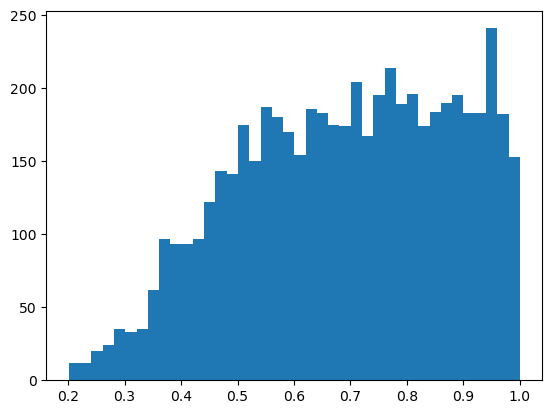

In [309]:
plt.hist(spirals['ba'],bins=40)

In [298]:
HI_spirals_cut = HI_spirals[np.abs(HI_spirals['ba'] - HI_spirals['nsa_elpetro_ba']) < 0.15]

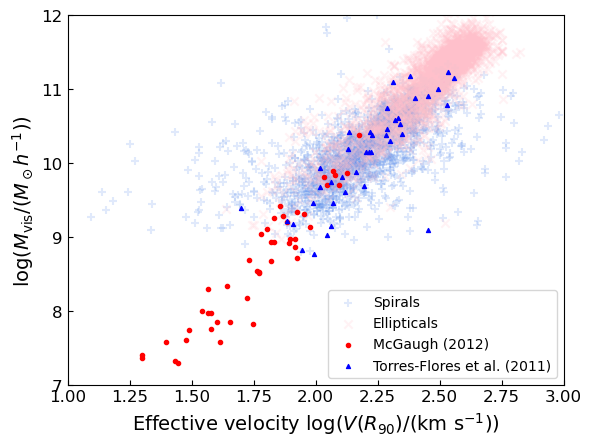

In [299]:
plt.scatter(np.log10(HI_spirals_cut['v_eff']), HI_spirals_cut['Mstar_MHI'], marker='+', color='cornflowerblue', alpha=0.2, label='Spirals')
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2, label='Ellipticals')
plt.xlim(1,3)
plt.ylim(7,12)
plt.tick_params( axis='both', direction='in', labelsize=12)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='.', color='r', label='McGaugh (2012)')
plt.scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='^', color='b', s=8, label='Torres-Flores et al. (2011)')
plt.legend()
# plt.savefig(plot_dir + 'BTFR_desmond_compare.png', bbox_inches='tight')

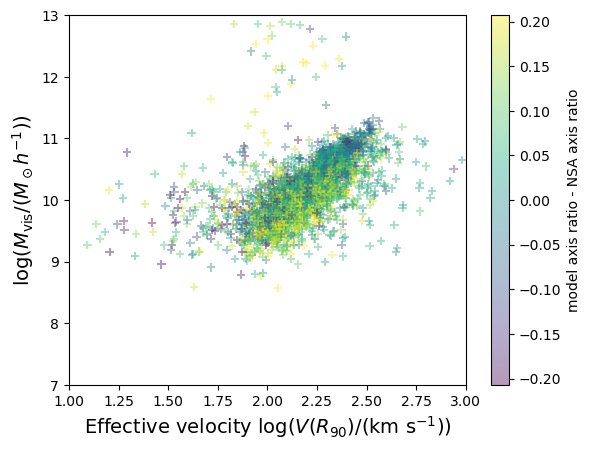

In [361]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', 
            c= HI_spirals['ba']-HI_spirals['nsa_elpetro_ba'], 
            alpha=0.4, label='Spirals')
plt.colorbar(label='model axis ratio - NSA axis ratio')
plt.xlim(1,3)
plt.ylim(7,13)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.savefig(plot_dir + 'spiral_ba_nsaba.png')

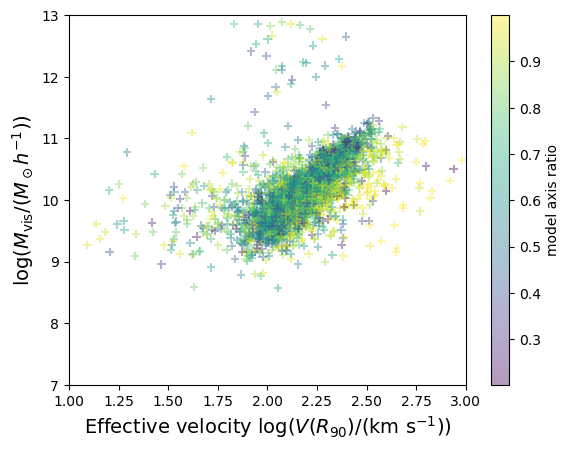

In [362]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', 
            c= HI_spirals['ba'], 
            alpha=0.4, label='Spirals')
plt.colorbar(label='model axis ratio')
plt.xlim(1,3)
plt.ylim(7,13)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.savefig(plot_dir + 'spiral_ba.png')

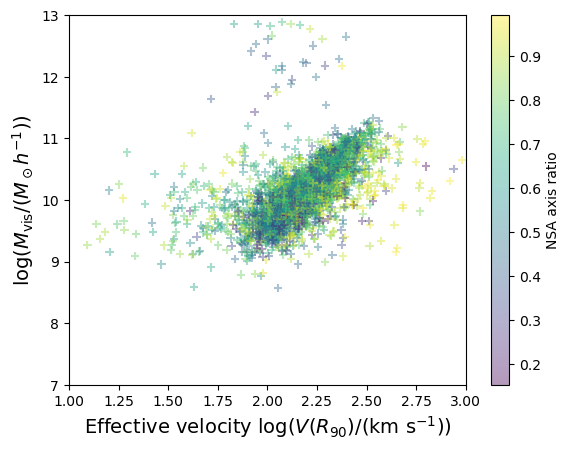

In [363]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', 
            c= HI_spirals['nsa_elpetro_ba'], 
            alpha=0.4, label='Spirals')
plt.colorbar(label='NSA axis ratio')
plt.xlim(1,3)
plt.ylim(7,13)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.savefig(plot_dir + 'spiral_nsaba.png')

In [88]:
HI_spirals[np.log10(HI_spirals['v_eff']) < 1.7]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90,count_M_star_0p1_R90,Mstar_tot,Mstar_MHI,v_eff
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,flo

(array([0.07413043, 0.02152174, 0.01434783, 0.01195652, 0.00478261,
        0.        , 0.00478261, 0.0023913 , 0.        , 0.0023913 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.0023913 , 0.00478261, 0.0023913 ,
        0.        , 0.        , 0.0023913 , 0.        , 0.0023913 ,
        0.0023913 , 0.        , 0.0023913 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.0023913 , 0.        , 0.        , 0.        ,
        0.        , 0.0023913 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.0023913 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

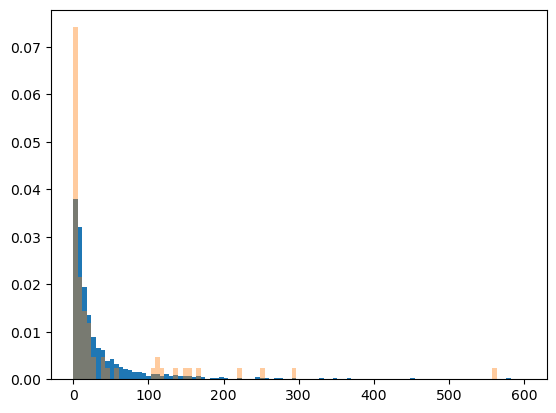

In [96]:
plt.hist(HI_spirals['chi2'], density=True, bins=np.linspace(0,600,100))
plt.hist(HI_spirals['chi2'][np.log10(HI_spirals['v_eff']) < 1.7], density=True, bins=np.linspace(0,600,100),alpha=0.4)


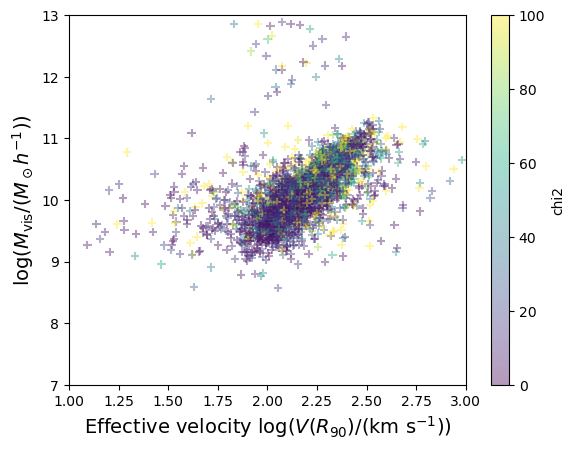

In [101]:
plt.scatter(np.log10(HI_spirals['v_eff']), HI_spirals['Mstar_MHI'], marker='+', 
            c= HI_spirals['chi2'], vmin=0, vmax=100,
            alpha=0.4, label='Spirals')
plt.colorbar(label='chi2')
plt.xlim(1,3)
plt.ylim(7,13)
plt.xlabel(r'Effective velocity $\log(V(R_{90})/(\text{km s}^{-1}))$', fontsize=14)
plt.ylabel(r'$\log(M_{\rm vis}/(M_\odot h^{-1}))$', fontsize=14)
plt.savefig(plot_dir + 'spiral_nsaba.png')

In [69]:
a = -0.387
deltaa = 0.003
2/(5* a**2) * deltaa

0.008012339002063176

In [73]:
a=-0.510
deltaa = 0.010

20/(-5*a-1)**2 * deltaa

0.08324661810613947